In [1]:
# ============================================================
# REPRODUCIBLE DATA SETUP — GITHUB
# ============================================================
# This notebook automatically retrieves the thesis repository in Google Colab.
# No manual upload of train_FD001.txt is required.

import os
import subprocess

REPO_URL = "https://github.com/dilawar1791/turbofan-rul-shap-thesis.git"
REPO_DIR = "/content/turbofan-rul-shap-thesis"

if not os.path.exists(REPO_DIR):
    subprocess.run(
        ["git", "clone", "--depth", "1", REPO_URL, REPO_DIR],
        check=True
    )

TRAIN_PATH = os.path.join(REPO_DIR, "data", "train_FD001.txt")

if not os.path.exists(TRAIN_PATH):
    raise FileNotFoundError(
        f"Required dataset file was not found: {TRAIN_PATH}"
    )

print("✓ train_FD001.txt found.")
print("Dataset path:", TRAIN_PATH)

✓ train_FD001.txt found.
Dataset path: /content/turbofan-rul-shap-thesis/data/train_FD001.txt


Dataset shape: (20631, 26)
   engine_id  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  \
0          1      1       -0.0007       -0.0004         100.0    518.67   
1          1      2        0.0019       -0.0003         100.0    518.67   
2          1      3       -0.0043        0.0003         100.0    518.67   
3          1      4        0.0007        0.0000         100.0    518.67   
4          1      5       -0.0019       -0.0002         100.0    518.67   

   sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  \
0    641.82   1589.70   1400.60     14.62  ...     521.66    2388.02   
1    642.15   1591.82   1403.14     14.62  ...     522.28    2388.07   
2    642.35   1587.99   1404.20     14.62  ...     522.42    2388.03   
3    642.35   1582.79   1401.87     14.62  ...     522.86    2388.08   
4    642.37   1582.85   1406.22     14.62  ...     522.19    2388.04   

   sensor_14  sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  \
0    8138.62     8

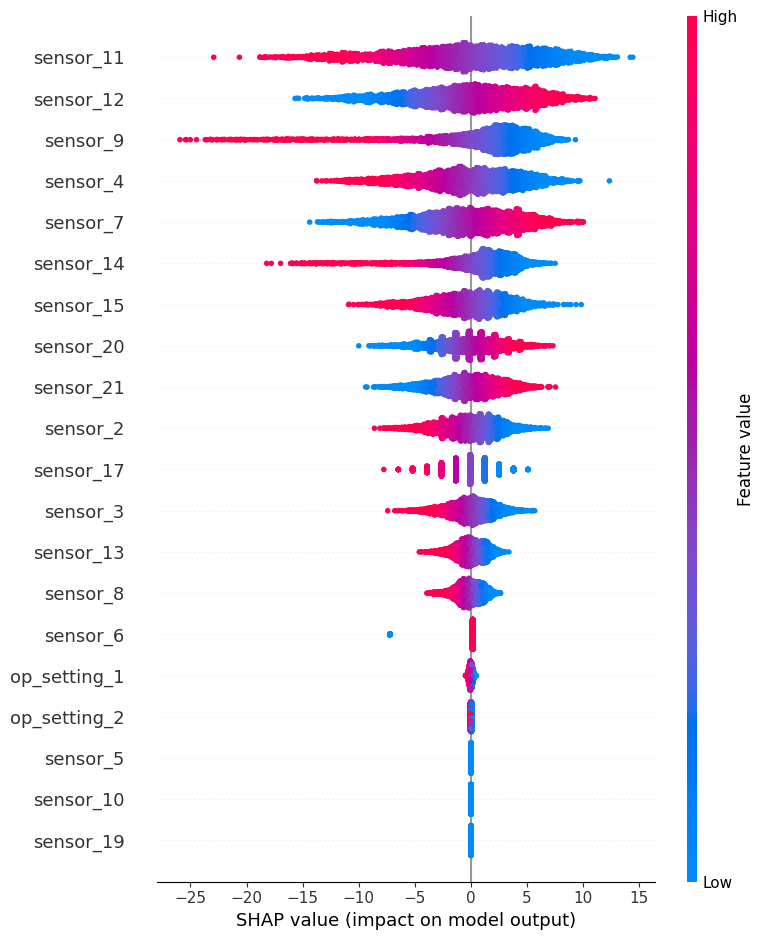

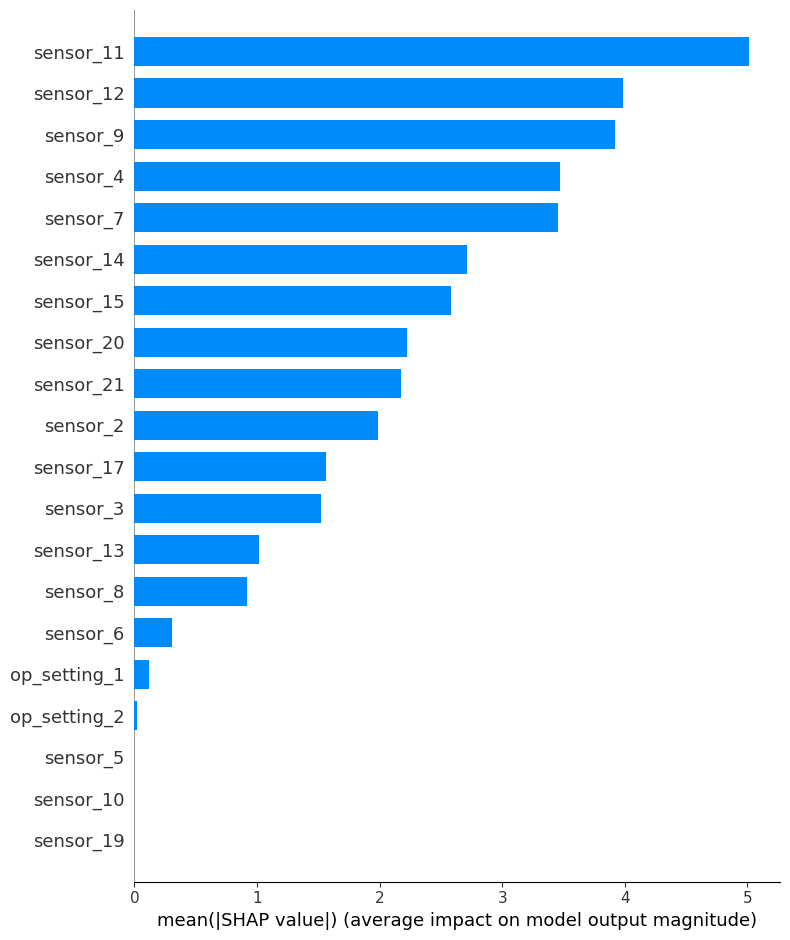


Generating SHAP for Random Forest Regressor...


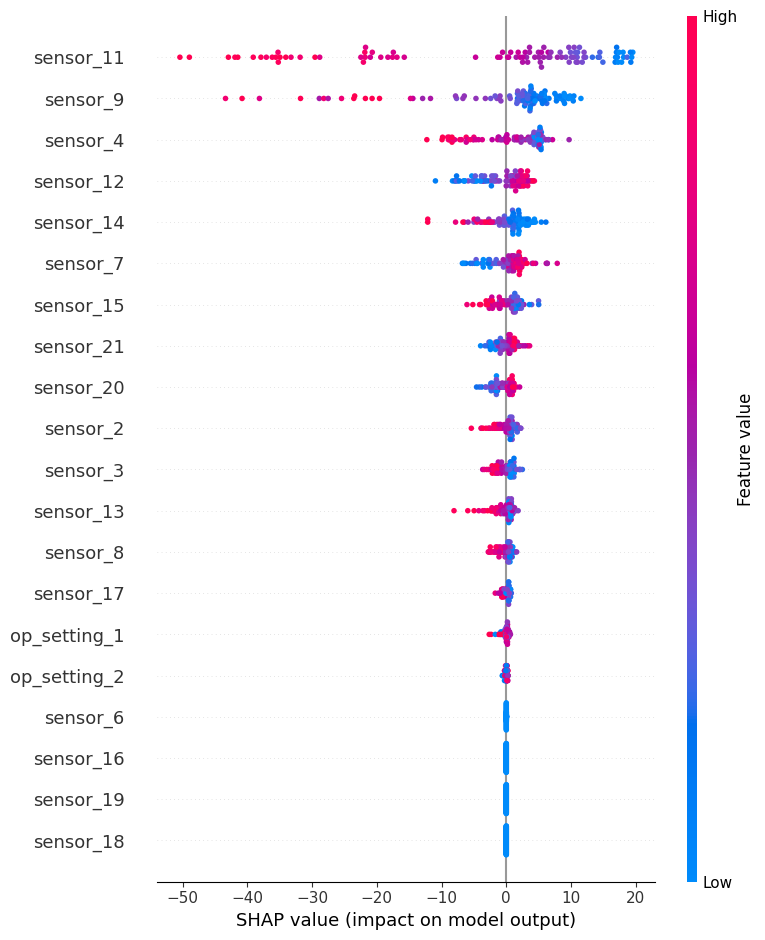

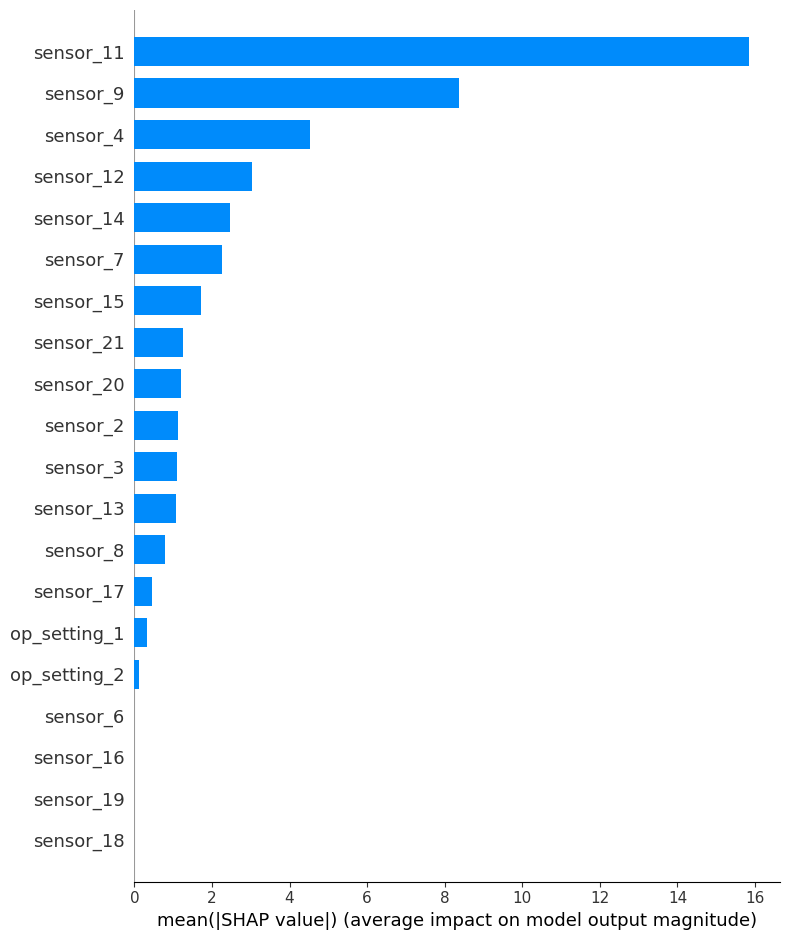


Generating SHAP for XGBoost Regressor...


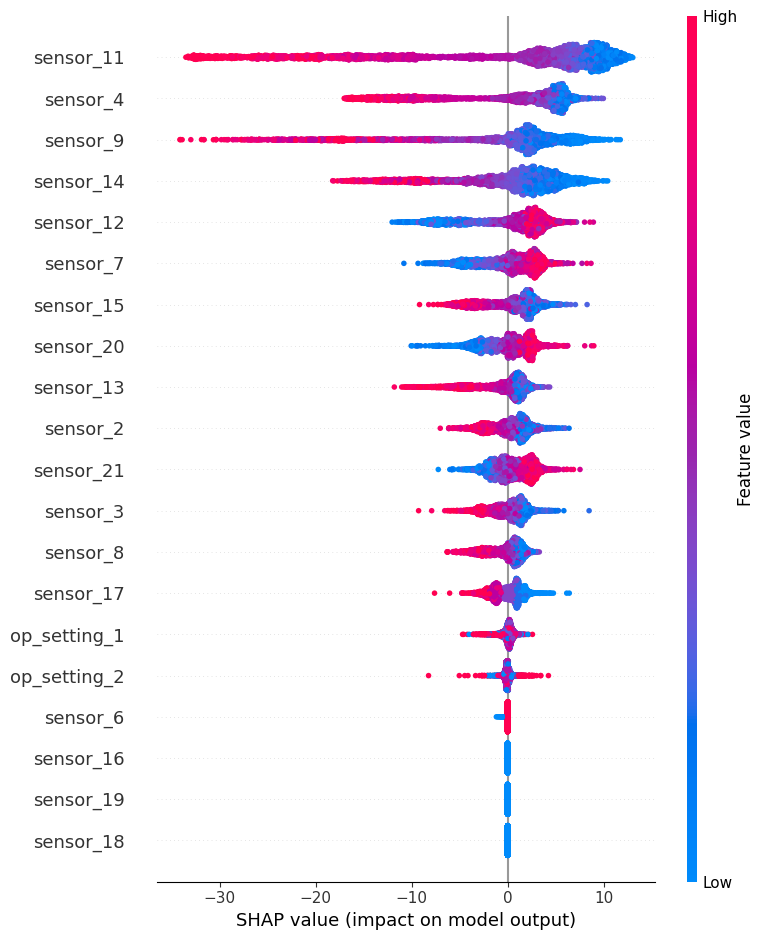

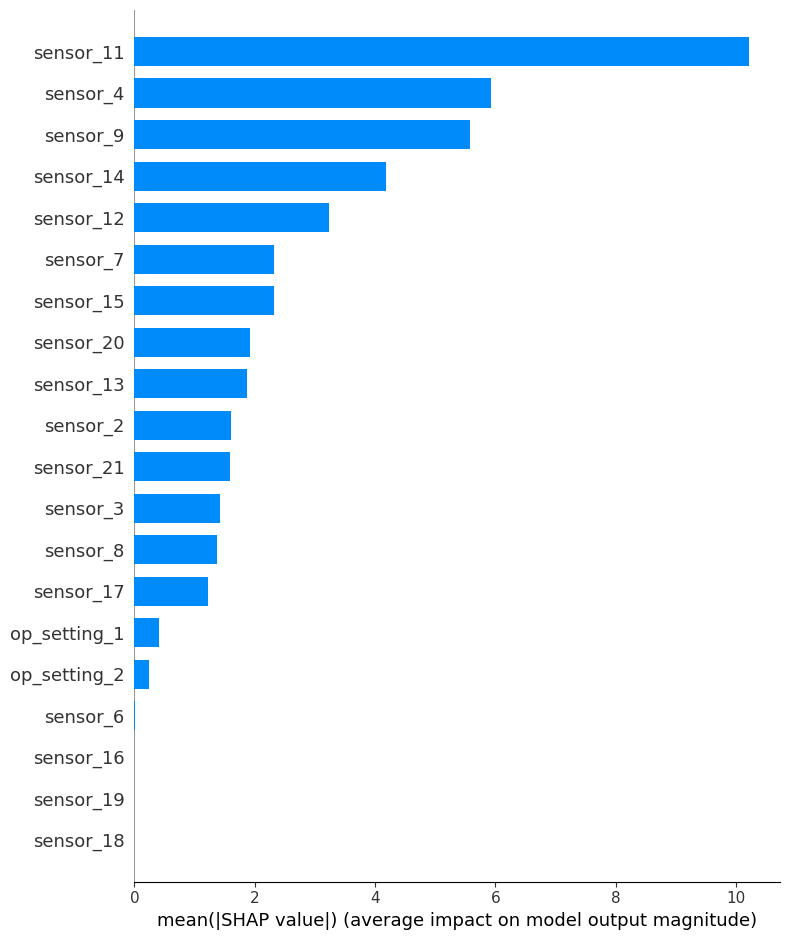


Top SHAP Features - Linear Regression
      Feature  Mean_SHAP
13  sensor_11   5.014414
14  sensor_12   3.981634
11   sensor_9   3.922654
6    sensor_4   3.474803
9    sensor_7   3.451789
16  sensor_14   2.710396
17  sensor_15   2.578669
22  sensor_20   2.226740
23  sensor_21   2.174206
4    sensor_2   1.988187

Top SHAP Features - Random Forest Regressor
      Feature  Mean_SHAP
13  sensor_11  15.850528
11   sensor_9   8.379627
6    sensor_4   4.523223
14  sensor_12   3.026628
16  sensor_14   2.478106
9    sensor_7   2.268787
17  sensor_15   1.719276
23  sensor_21   1.259926
22  sensor_20   1.204844
4    sensor_2   1.117499

Top SHAP Features - XGBoost Regressor
      Feature  Mean_SHAP
13  sensor_11  10.217508
6    sensor_4   5.924320
11   sensor_9   5.573921
16  sensor_14   4.176697
14  sensor_12   3.235369
9    sensor_7   2.326327
17  sensor_15   2.326119
22  sensor_20   1.919750
15  sensor_13   1.871733
4    sensor_2   1.604949

Random State Stability Results
   Random_State     

In [2]:
# ============================================================
# RUL Prediction of Turbofan Engines using ML + SHAP
# Dataset: NASA CMAPSS FD001
# ============================================================

# ----------------------------
# 1. Import Libraries
# ----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, f1_score, classification_report

from xgboost import XGBRegressor, XGBClassifier


# ----------------------------
# 2. Load Dataset
# ----------------------------

columns = (
    ['engine_id', 'cycle'] +
    ['op_setting_1', 'op_setting_2', 'op_setting_3'] +
    [f'sensor_{i}' for i in range(1, 22)]
)

train = pd.read_csv(
    TRAIN_PATH,
    sep=r"\s+",
    header=None,
    names=columns
)

print("Dataset shape:", train.shape)
print(train.head())


# ----------------------------
# 3. Calculate RUL
# ----------------------------

max_cycle = train.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id', 'max_cycle']

train = train.merge(max_cycle, on='engine_id', how='left')
train['RUL'] = train['max_cycle'] - train['cycle']

print("Maximum uncapped RUL:", train['RUL'].max())


# ----------------------------
# 4. Cap RUL at 125
# ----------------------------

train['RUL'] = train['RUL'].clip(upper=125)

print(train['RUL'].describe())


# ----------------------------
# 5. Feature Selection
# ----------------------------

drop_cols = ['engine_id', 'cycle', 'max_cycle', 'RUL']

X_full = train.drop(columns=drop_cols)
y_full = train['RUL']

print("Total features:", X_full.shape[1])
print(X_full.columns)


# ----------------------------
# 6. Engine-wise Train-Test Split
# ----------------------------

engine_ids = train['engine_id'].unique()

train_ids, test_ids = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_data = train[train['engine_id'].isin(train_ids)]
test_data = train[train['engine_id'].isin(test_ids)]

X_train = X_full.loc[train_data.index]
y_train = train_data['RUL']

X_test = X_full.loc[test_data.index]
y_test = test_data['RUL']

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


# ----------------------------
# 7. Linear Regression
# ----------------------------

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("\nLinear Regression")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)


# ----------------------------
# 8. Random Forest Regressor
# ----------------------------

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("\nRandom Forest Regressor")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)


# ----------------------------
# 9. XGBoost Regressor
# ----------------------------

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print("\nXGBoost Regressor")
print("RMSE:", rmse_xgb)
print("MAE:", mae_xgb)


# ----------------------------
# 10. Regression Results Table
# ----------------------------

results_reg = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'MAE': [mae_lr, mae_rf, mae_xgb]
})

print("\nRegression Results")
print(results_reg)


# ----------------------------
# 11. Classification Target
# RUL < 30 = failure risk
# ----------------------------

train['failure'] = (train['RUL'] < 30).astype(int)

train_data = train[train['engine_id'].isin(train_ids)]
test_data = train[train['engine_id'].isin(test_ids)]

X_train_cls = X_full.loc[train_data.index]
X_test_cls = X_full.loc[test_data.index]

y_train_cls = train_data['failure']
y_test_cls = test_data['failure']


# ----------------------------
# 12. Random Forest Classifier
# ----------------------------

rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train_cls, y_train_cls)

y_pred_rf_cls = rf_clf.predict(X_test_cls)

acc_rf_cls = accuracy_score(y_test_cls, y_pred_rf_cls)
f1_rf_cls = f1_score(y_test_cls, y_pred_rf_cls)

print("\nRandom Forest Classifier")
print("Accuracy:", acc_rf_cls)
print("F1-score:", f1_rf_cls)
print(classification_report(y_test_cls, y_pred_rf_cls))


# ----------------------------
# 13. XGBoost Classifier
# ----------------------------

xgb_clf = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_clf.fit(X_train_cls, y_train_cls)

y_pred_xgb_cls = xgb_clf.predict(X_test_cls)

acc_xgb_cls = accuracy_score(y_test_cls, y_pred_xgb_cls)
f1_xgb_cls = f1_score(y_test_cls, y_pred_xgb_cls)

print("\nXGBoost Classifier")
print("Accuracy:", acc_xgb_cls)
print("F1-score:", f1_xgb_cls)
print(classification_report(y_test_cls, y_pred_xgb_cls))


# ----------------------------
# 14. Classification Results Table
# ----------------------------

results_cls = pd.DataFrame({
    'Model': ['Random Forest Classifier', 'XGBoost Classifier'],
    'Accuracy': [acc_rf_cls, acc_xgb_cls],
    'F1-score': [f1_rf_cls, f1_xgb_cls]
})

print("\nClassification Results")
print(results_cls)


# ----------------------------
# 15. SHAP for Linear Regression
# ----------------------------

print("\nGenerating SHAP for Linear Regression...")

background_lr = shap.sample(X_train, 100, random_state=42)

explainer_lr = shap.Explainer(lr_model, background_lr)
shap_values_lr = explainer_lr(X_test)

shap.summary_plot(shap_values_lr, X_test)
shap.summary_plot(shap_values_lr, X_test, plot_type="bar")



# ----------------------------
# 16. SHAP for Random Forest Regressor
# ----------------------------

print("\nGenerating SHAP for Random Forest Regressor...")

# Use only 100 test samples for faster SHAP calculation
X_test_rf_sample = X_test.sample(100, random_state=42)

explainer_rf = shap.TreeExplainer(
    rf,
    feature_perturbation="tree_path_dependent"
)

shap_values_rf = explainer_rf.shap_values(X_test_rf_sample)

shap.summary_plot(shap_values_rf, X_test_rf_sample)
shap.summary_plot(shap_values_rf, X_test_rf_sample, plot_type="bar")


# ----------------------------
# 17. SHAP for XGBoost Regressor
# ----------------------------

print("\nGenerating SHAP for XGBoost Regressor...")

explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)

shap.summary_plot(shap_values_xgb, X_test)
shap.summary_plot(shap_values_xgb, X_test, plot_type="bar")


# ----------------------------
# 18. Mean SHAP Importance Tables
# ----------------------------

def mean_shap_table(shap_values, X, model_name):
    values = np.abs(shap_values).mean(axis=0)

    table = pd.DataFrame({
        'Feature': X.columns,
        'Mean_SHAP': values
    }).sort_values(by='Mean_SHAP', ascending=False)

    print(f"\nTop SHAP Features - {model_name}")
    print(table.head(10))

    return table


# For Linear Regression SHAP object
lr_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_SHAP': np.abs(shap_values_lr.values).mean(axis=0)
}).sort_values(by='Mean_SHAP', ascending=False)

print("\nTop SHAP Features - Linear Regression")
print(lr_importance.head(10))


rf_importance = mean_shap_table(
    shap_values_rf,
    X_test_rf_sample,
    "Random Forest Regressor"
)

xgb_importance = mean_shap_table(
    shap_values_xgb,
    X_test,
    "XGBoost Regressor"
)


# ----------------------------
# 19. Random State Stability for XGBoost
# ----------------------------

random_states = [42, 100, 200, 300, 500]
stability_results = []

for rs in random_states:
    engine_ids = train['engine_id'].unique()

    train_ids_rs, test_ids_rs = train_test_split(
        engine_ids,
        test_size=0.2,
        random_state=rs
    )

    train_data_rs = train[train['engine_id'].isin(train_ids_rs)]
    test_data_rs = train[train['engine_id'].isin(test_ids_rs)]

    X_train_rs = X_full.loc[train_data_rs.index]
    y_train_rs = train_data_rs['RUL']

    X_test_rs = X_full.loc[test_data_rs.index]
    y_test_rs = test_data_rs['RUL']

    xgb_rs = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=rs,
        objective='reg:squarederror'
    )

    xgb_rs.fit(X_train_rs, y_train_rs)

    y_pred_rs = xgb_rs.predict(X_test_rs)

    rmse_rs = np.sqrt(mean_squared_error(y_test_rs, y_pred_rs))
    mae_rs = mean_absolute_error(y_test_rs, y_pred_rs)

    stability_results.append({
        'Random_State': rs,
        'RMSE': rmse_rs,
        'MAE': mae_rs
    })

stability_table = pd.DataFrame(stability_results)

print("\nRandom State Stability Results")
print(stability_table)


# ----------------------------
# 20. Hyperparameter Stability for XGBoost
# ----------------------------

xgb_configs = {
    'Baseline': {
        'n_estimators': 300,
        'max_depth': 6,
        'learning_rate': 0.05
    },
    'Simple': {
        'n_estimators': 100,
        'max_depth': 3,
        'learning_rate': 0.1
    },
    'Complex': {
        'n_estimators': 500,
        'max_depth': 8,
        'learning_rate': 0.03
    }
}

hyper_results = []

for name, params in xgb_configs.items():

    model = XGBRegressor(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    hyper_results.append({
        'Configuration': name,
        'n_estimators': params['n_estimators'],
        'max_depth': params['max_depth'],
        'learning_rate': params['learning_rate'],
        'RMSE': rmse,
        'MAE': mae
    })

hyper_table = pd.DataFrame(hyper_results)

print("\nXGBoost Hyperparameter Stability Results")
print(hyper_table)


# ----------------------------
# 21. Failure Probability using XGBoost Classifier
# ----------------------------

failure_prob = xgb_clf.predict_proba(X_test_cls)[:, 1]

probability_table = pd.DataFrame({
    'Actual_Failure': y_test_cls.values,
    'Predicted_Failure': y_pred_xgb_cls,
    'Failure_Probability': failure_prob
})

print("\nFailure Probability Examples")
print(probability_table.head(20))


# ----------------------------
# 22. Save Results
# ----------------------------

results_reg.to_csv("regression_results.csv", index=False)
results_cls.to_csv("classification_results.csv", index=False)
stability_table.to_csv("random_state_stability.csv", index=False)
hyper_table.to_csv("hyperparameter_stability.csv", index=False)

lr_importance.to_csv("shap_linear_regression.csv", index=False)
rf_importance.to_csv("shap_random_forest.csv", index=False)
xgb_importance.to_csv("shap_xgboost.csv", index=False)

print("\nAll results saved successfully.")

In [3]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np

# Create ranking dictionaries
lr_rank = lr_importance.reset_index(drop=True)
lr_rank["Rank"] = range(1, len(lr_rank) + 1)

rf_rank = rf_importance.reset_index(drop=True)
rf_rank["Rank"] = range(1, len(rf_rank) + 1)

xgb_rank = xgb_importance.reset_index(drop=True)
xgb_rank["Rank"] = range(1, len(xgb_rank) + 1)

# Merge rankings by feature
ranking_df = (
    lr_rank[["Feature", "Rank"]]
    .rename(columns={"Rank": "LR"})
    .merge(
        rf_rank[["Feature", "Rank"]].rename(columns={"Rank": "RF"}),
        on="Feature"
    )
    .merge(
        xgb_rank[["Feature", "Rank"]].rename(columns={"Rank": "XGB"}),
        on="Feature"
    )
)

print(ranking_df)

         Feature  LR  RF  XGB
0      sensor_11   1   1    1
1      sensor_12   2   4    5
2       sensor_9   3   2    3
3       sensor_4   4   3    2
4       sensor_7   5   6    6
5      sensor_14   6   5    4
6      sensor_15   7   7    7
7      sensor_20   8   9    8
8      sensor_21   9   8   11
9       sensor_2  10  10   10
10     sensor_17  11  14   14
11      sensor_3  12  11   12
12     sensor_13  13  12    9
13      sensor_8  14  13   13
14      sensor_6  15  17   17
15  op_setting_1  16  15   15
16  op_setting_2  17  16   16
17      sensor_5  18  18   18
18     sensor_10  19  21   21
19      sensor_1  20  20   20
20  op_setting_3  21  19   19
21     sensor_16  22  22   22
22     sensor_19  23  23   23
23     sensor_18  24  24   24


In [4]:
models = ["LR", "RF", "XGB"]

spearman_matrix = pd.DataFrame(index=models, columns=models)

for m1 in models:
    for m2 in models:
        corr, _ = spearmanr(ranking_df[m1], ranking_df[m2])
        spearman_matrix.loc[m1, m2] = round(corr, 3)

print("\nSpearman Rank Correlation Matrix")
print(spearman_matrix)


Spearman Rank Correlation Matrix
        LR     RF    XGB
LR     1.0  0.984  0.973
RF   0.984    1.0   0.99
XGB  0.973   0.99    1.0


In [5]:
values = []

for i in range(len(models)):
    for j in range(i+1, len(models)):
        values.append(float(spearman_matrix.iloc[i, j]))

print("Mean Spearman:", np.mean(values))
print("Std Spearman :", np.std(values))

Mean Spearman: 0.9823333333333334
Std Spearman : 0.007039570693980965


In [6]:
print(spearman_matrix)
print("Mean Spearman:", np.mean(values))
print("Std Spearman :", np.std(values))

        LR     RF    XGB
LR     1.0  0.984  0.973
RF   0.984    1.0   0.99
XGB  0.973   0.99    1.0
Mean Spearman: 0.9823333333333334
Std Spearman : 0.007039570693980965


In [7]:
def jaccard(topA, topB):
    A = set(topA)
    B = set(topB)
    return len(A & B) / len(A | B)

top_k = 5

top_lr = lr_importance.head(top_k)["Feature"]
top_rf = rf_importance.head(top_k)["Feature"]
top_xgb = xgb_importance.head(top_k)["Feature"]

jaccard_matrix = pd.DataFrame(index=models, columns=models)

feature_sets = {
    "LR": top_lr,
    "RF": top_rf,
    "XGB": top_xgb
}

for m1 in models:
    for m2 in models:
        score = jaccard(feature_sets[m1], feature_sets[m2])
        jaccard_matrix.loc[m1, m2] = round(score, 3)

print("\nJaccard Similarity Matrix")
print(jaccard_matrix)


Jaccard Similarity Matrix
        LR     RF    XGB
LR     1.0  0.667  0.667
RF   0.667    1.0    1.0
XGB  0.667    1.0    1.0


In [8]:
values = []

for i in range(len(models)):
    for j in range(i+1, len(models)):
        values.append(float(jaccard_matrix.iloc[i, j]))

print("Mean Jaccard:", np.mean(values))
print("Std Jaccard :", np.std(values))

Mean Jaccard: 0.778
Std Jaccard : 0.15697770542341352


In [9]:
train
X_full
engine_ids

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

In [ ]:
# ============================================================
# SHAP STABILITY ANALYSIS
# All three regression models
# ============================================================

import numpy as np
import pandas as pd
import shap

from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


# ============================================================
# SETTINGS
# ============================================================

split_states = [42, 100, 200, 300, 500]

# Keep this moderate so Random Forest SHAP remains fast
SHAP_SAMPLE_SIZE = 300
TOP_K = 5

model_names = [
    "Linear Regression",
    "Random Forest",
    "XGBoost"
]


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def extract_shap_array(shap_output):
    """
    Converts SHAP output to a normal NumPy array.
    Supports both shap.Explanation and ndarray outputs.
    """
    if hasattr(shap_output, "values"):
        return np.asarray(shap_output.values)

    return np.asarray(shap_output)


def create_ranking(feature_names, shap_values):
    """
    Calculates global SHAP importance using mean absolute SHAP
    and returns features ordered from most to least important.
    """
    values = extract_shap_array(shap_values)

    mean_abs_shap = np.abs(values).mean(axis=0)

    ranking = pd.DataFrame({
        "Feature": feature_names,
        "Mean_SHAP": mean_abs_shap
    }).sort_values(
        "Mean_SHAP",
        ascending=False
    ).reset_index(drop=True)

    ranking["Rank"] = np.arange(1, len(ranking) + 1)

    return ranking


def rankings_to_dataframe(rankings):
    """
    Converts a dictionary of rankings into one feature-rank table.
    """
    rank_columns = {}

    for name, table in rankings.items():
        rank_columns[name] = table.set_index("Feature")["Rank"]

    return pd.DataFrame(rank_columns).sort_index()


def spearman_similarity_matrix(rankings):
    """
    Calculates pairwise Spearman correlation between complete rankings.
    """
    rank_df = rankings_to_dataframe(rankings)
    names = list(rank_df.columns)

    matrix = pd.DataFrame(
        index=names,
        columns=names,
        dtype=float
    )

    for name_1 in names:
        for name_2 in names:
            correlation, _ = spearmanr(
                rank_df[name_1],
                rank_df[name_2]
            )
            matrix.loc[name_1, name_2] = correlation

    return matrix


def jaccard_similarity_matrix(rankings, top_k=5):
    """
    Calculates pairwise Jaccard similarity for the Top-k features.
    """
    names = list(rankings.keys())

    top_feature_sets = {
        name: set(table.head(top_k)["Feature"])
        for name, table in rankings.items()
    }

    matrix = pd.DataFrame(
        index=names,
        columns=names,
        dtype=float
    )

    for name_1 in names:
        for name_2 in names:
            set_1 = top_feature_sets[name_1]
            set_2 = top_feature_sets[name_2]

            intersection = len(set_1.intersection(set_2))
            union = len(set_1.union(set_2))

            matrix.loc[name_1, name_2] = intersection / union

    return matrix


def pairwise_summary(matrix):
    """
    Returns mean and population standard deviation of unique
    pairwise values, excluding the diagonal.
    """
    values = []

    for i in range(len(matrix)):
        for j in range(i + 1, len(matrix)):
            values.append(float(matrix.iloc[i, j]))

    return {
        "Mean": np.mean(values),
        "Standard_Deviation": np.std(values),
        "Minimum": np.min(values),
        "Maximum": np.max(values),
        "Pairwise_Values": values
    }


def show_top_features(rankings, top_k=5):
    """
    Creates a rank-by-rank comparison table.
    """
    output = {}

    for name, table in rankings.items():
        output[name] = table.head(top_k)["Feature"].tolist()

    comparison = pd.DataFrame(
        output,
        index=np.arange(1, top_k + 1)
    )

    comparison.index.name = "Rank"

    return comparison


# ============================================================
# PART A
# SHAP STABILITY ACROSS DIFFERENT ENGINE SPLITS
# ALL THREE MODELS
# ============================================================

all_split_rankings = {
    "Linear Regression": {},
    "Random Forest": {},
    "XGBoost": {}
}

split_performance = []

for split_state in split_states:

    print(f"\nRunning split state {split_state}...")

    # --------------------------------------------------------
    # Engine-wise split
    # --------------------------------------------------------

    train_ids_state, test_ids_state = train_test_split(
        engine_ids,
        test_size=0.20,
        random_state=split_state
    )

    train_state = train[
        train["engine_id"].isin(train_ids_state)
    ]

    test_state = train[
        train["engine_id"].isin(test_ids_state)
    ]

    X_train_state = X_full.loc[train_state.index]
    y_train_state = train_state["RUL"]

    X_test_state = X_full.loc[test_state.index]
    y_test_state = test_state["RUL"]

    # Use a reproducible test subset for SHAP
    sample_n = min(SHAP_SAMPLE_SIZE, len(X_test_state))

    X_shap_state = X_test_state.sample(
        n=sample_n,
        random_state=42
    )

    # --------------------------------------------------------
    # Linear Regression
    # --------------------------------------------------------

    lr_state = LinearRegression()
    lr_state.fit(X_train_state, y_train_state)

    background_n = min(100, len(X_train_state))

    lr_background = shap.sample(
        X_train_state,
        background_n,
        random_state=42
    )

    lr_explainer = shap.Explainer(
        lr_state,
        lr_background
    )

    lr_shap = lr_explainer(X_shap_state)

    lr_ranking = create_ranking(
        X_shap_state.columns,
        lr_shap
    )

    all_split_rankings[
        "Linear Regression"
    ][f"Split_{split_state}"] = lr_ranking

    # --------------------------------------------------------
    # Random Forest
    # --------------------------------------------------------

    rf_state = RandomForestRegressor(
        n_estimators=150,
        max_depth=15,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )

    rf_state.fit(X_train_state, y_train_state)

    rf_explainer = shap.TreeExplainer(rf_state)
    rf_shap = rf_explainer.shap_values(X_shap_state)

    rf_ranking = create_ranking(
        X_shap_state.columns,
        rf_shap
    )

    all_split_rankings[
        "Random Forest"
    ][f"Split_{split_state}"] = rf_ranking

    # --------------------------------------------------------
    # XGBoost
    # --------------------------------------------------------

    xgb_state = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    xgb_state.fit(X_train_state, y_train_state)

    xgb_explainer = shap.TreeExplainer(xgb_state)
    xgb_shap = xgb_explainer.shap_values(X_shap_state)

    xgb_ranking = create_ranking(
        X_shap_state.columns,
        xgb_shap
    )

    all_split_rankings[
        "XGBoost"
    ][f"Split_{split_state}"] = xgb_ranking

    print(f"Finished split state {split_state}")


# ============================================================
# RESULTS FOR SPLIT-STATE STABILITY
# ============================================================

split_summary_rows = []

for model_name in model_names:

    print("\n" + "=" * 60)
    print(f"{model_name}: SHAP stability across engine splits")
    print("=" * 60)

    rankings = all_split_rankings[model_name]

    spearman_matrix = spearman_similarity_matrix(rankings)
    jaccard_matrix = jaccard_similarity_matrix(
        rankings,
        top_k=TOP_K
    )

    spearman_summary = pairwise_summary(spearman_matrix)
    jaccard_summary = pairwise_summary(jaccard_matrix)

    print("\nTop-5 feature comparison:")
    print(show_top_features(rankings, top_k=TOP_K))

    print("\nSpearman matrix:")
    print(spearman_matrix.round(3))

    print(
        "\nSpearman mean ± SD:",
        f"{spearman_summary['Mean']:.3f} ± "
        f"{spearman_summary['Standard_Deviation']:.3f}"
    )

    print("\nJaccard Top-5 matrix:")
    print(jaccard_matrix.round(3))

    print(
        "\nJaccard mean ± SD:",
        f"{jaccard_summary['Mean']:.3f} ± "
        f"{jaccard_summary['Standard_Deviation']:.3f}"
    )

    split_summary_rows.append({
        "Model": model_name,
        "Spearman_Mean": spearman_summary["Mean"],
        "Spearman_SD": spearman_summary["Standard_Deviation"],
        "Jaccard_Top5_Mean": jaccard_summary["Mean"],
        "Jaccard_Top5_SD": jaccard_summary[
            "Standard_Deviation"
        ]
    })

    safe_name = model_name.lower().replace(" ", "_")

    spearman_matrix.round(4).to_csv(
        f"{safe_name}_split_spearman_matrix.csv"
    )

    jaccard_matrix.round(4).to_csv(
        f"{safe_name}_split_jaccard_top5_matrix.csv"
    )

    show_top_features(
        rankings,
        top_k=10
    ).to_csv(
        f"{safe_name}_split_top10_comparison.csv"
    )


split_stability_summary = pd.DataFrame(split_summary_rows)

print("\nOverall split-state SHAP stability summary:")
print(split_stability_summary.round(4))

split_stability_summary.to_csv(
    "all_models_split_shap_stability_summary.csv",
    index=False
)


# ============================================================
# PART B
# RANDOM FOREST HYPERPARAMETER SHAP STABILITY
# Uses your original X_train and X_test
# ============================================================

rf_configurations = {
    "RF_Baseline": {
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_leaf": 3
    },
    "RF_Simple": {
        "n_estimators": 100,
        "max_depth": 10,
        "min_samples_leaf": 5
    },
    "RF_Complex": {
        "n_estimators": 500,
        "max_depth": None,
        "min_samples_leaf": 1
    }
}

rf_hyper_rankings = {}

X_rf_shap = X_test.sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_test)),
    random_state=42
)

for config_name, params in rf_configurations.items():

    print(f"\nTraining {config_name}...")

    model = RandomForestRegressor(
        **params,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_rf_shap)

    rf_hyper_rankings[config_name] = create_ranking(
        X_rf_shap.columns,
        shap_values
    )

    print(f"Finished {config_name}")


rf_hyper_spearman = spearman_similarity_matrix(
    rf_hyper_rankings
)

rf_hyper_jaccard = jaccard_similarity_matrix(
    rf_hyper_rankings,
    top_k=TOP_K
)

rf_hyper_spearman_summary = pairwise_summary(
    rf_hyper_spearman
)

rf_hyper_jaccard_summary = pairwise_summary(
    rf_hyper_jaccard
)

print("\nRandom Forest hyperparameter Top-10 comparison:")
print(show_top_features(rf_hyper_rankings, top_k=10))

print("\nRandom Forest hyperparameter Spearman matrix:")
print(rf_hyper_spearman.round(3))

print(
    "Mean ± SD:",
    f"{rf_hyper_spearman_summary['Mean']:.3f} ± "
    f"{rf_hyper_spearman_summary['Standard_Deviation']:.3f}"
)

print("\nRandom Forest hyperparameter Jaccard Top-5 matrix:")
print(rf_hyper_jaccard.round(3))

print(
    "Mean ± SD:",
    f"{rf_hyper_jaccard_summary['Mean']:.3f} ± "
    f"{rf_hyper_jaccard_summary['Standard_Deviation']:.3f}"
)


# ============================================================
# PART C
# XGBOOST HYPERPARAMETER SHAP STABILITY
# ============================================================

xgb_configurations = {
    "XGB_Baseline": {
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.05
    },
    "XGB_Simple": {
        "n_estimators": 100,
        "max_depth": 3,
        "learning_rate": 0.10
    },
    "XGB_Complex": {
        "n_estimators": 500,
        "max_depth": 8,
        "learning_rate": 0.03
    }
}

xgb_hyper_rankings = {}

X_xgb_shap = X_test.sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_test)),
    random_state=42
)

for config_name, params in xgb_configurations.items():

    print(f"\nTraining {config_name}...")

    model = XGBRegressor(
        **params,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_xgb_shap)

    xgb_hyper_rankings[config_name] = create_ranking(
        X_xgb_shap.columns,
        shap_values
    )

    print(f"Finished {config_name}")


xgb_hyper_spearman = spearman_similarity_matrix(
    xgb_hyper_rankings
)

xgb_hyper_jaccard = jaccard_similarity_matrix(
    xgb_hyper_rankings,
    top_k=TOP_K
)

xgb_hyper_spearman_summary = pairwise_summary(
    xgb_hyper_spearman
)

xgb_hyper_jaccard_summary = pairwise_summary(
    xgb_hyper_jaccard
)

print("\nXGBoost hyperparameter Top-10 comparison:")
print(show_top_features(xgb_hyper_rankings, top_k=10))

print("\nXGBoost hyperparameter Spearman matrix:")
print(xgb_hyper_spearman.round(3))

print(
    "Mean ± SD:",
    f"{xgb_hyper_spearman_summary['Mean']:.3f} ± "
    f"{xgb_hyper_spearman_summary['Standard_Deviation']:.3f}"
)

print("\nXGBoost hyperparameter Jaccard Top-5 matrix:")
print(xgb_hyper_jaccard.round(3))

print(
    "Mean ± SD:",
    f"{xgb_hyper_jaccard_summary['Mean']:.3f} ± "
    f"{xgb_hyper_jaccard_summary['Standard_Deviation']:.3f}"
)


# ============================================================
# FINAL HYPERPARAMETER SUMMARY TABLE
# ============================================================

hyperparameter_stability_summary = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Spearman_Mean":
            rf_hyper_spearman_summary["Mean"],
        "Spearman_SD":
            rf_hyper_spearman_summary["Standard_Deviation"],
        "Jaccard_Top5_Mean":
            rf_hyper_jaccard_summary["Mean"],
        "Jaccard_Top5_SD":
            rf_hyper_jaccard_summary["Standard_Deviation"]
    },
    {
        "Model": "XGBoost",
        "Spearman_Mean":
            xgb_hyper_spearman_summary["Mean"],
        "Spearman_SD":
            xgb_hyper_spearman_summary[
                "Standard_Deviation"
            ],
        "Jaccard_Top5_Mean":
            xgb_hyper_jaccard_summary["Mean"],
        "Jaccard_Top5_SD":
            xgb_hyper_jaccard_summary[
                "Standard_Deviation"
            ]
    }
])

print("\nFinal hyperparameter SHAP stability summary:")
print(hyperparameter_stability_summary.round(4))


# ============================================================
# SAVE RESULTS
# ============================================================

rf_hyper_spearman.round(4).to_csv(
    "rf_hyperparameter_spearman_matrix.csv"
)

rf_hyper_jaccard.round(4).to_csv(
    "rf_hyperparameter_jaccard_top5_matrix.csv"
)

show_top_features(
    rf_hyper_rankings,
    top_k=10
).to_csv(
    "rf_hyperparameter_top10_comparison.csv"
)

xgb_hyper_spearman.round(4).to_csv(
    "xgb_hyperparameter_spearman_matrix.csv"
)

xgb_hyper_jaccard.round(4).to_csv(
    "xgb_hyperparameter_jaccard_top5_matrix.csv"
)

show_top_features(
    xgb_hyper_rankings,
    top_k=10
).to_csv(
    "xgb_hyperparameter_top10_comparison.csv"
)

hyperparameter_stability_summary.to_csv(
    "hyperparameter_shap_stability_summary.csv",
    index=False
)

print("\nAll SHAP stability results saved successfully.")


Running split state 42...
Finished split state 42

Running split state 100...
Finished split state 100

Running split state 200...
Finished split state 200

Running split state 300...
Finished split state 300

Running split state 500...
Finished split state 500

Linear Regression: SHAP stability across engine splits

Top-5 feature comparison:
       Split_42  Split_100  Split_200  Split_300  Split_500
Rank                                                       
1     sensor_11   sensor_9  sensor_11  sensor_11  sensor_11
2     sensor_12  sensor_11  sensor_12  sensor_12  sensor_12
3      sensor_9  sensor_12   sensor_7   sensor_4   sensor_9
4      sensor_4  sensor_14   sensor_4   sensor_7  sensor_14
5      sensor_7   sensor_4   sensor_9   sensor_9   sensor_4

Spearman matrix:
           Split_42  Split_100  Split_200  Split_300  Split_500
Split_42      1.000      0.992      0.993      0.991      0.993
Split_100     0.992      1.000      0.981      0.975      0.994
Split_200     0.993     

In [ ]:
# ============================================================
# SENSOR-NOISE ROBUSTNESS ANALYSIS FOR XGBOOST
# ============================================================

import numpy as np
import pandas as pd
import shap

from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error, mean_absolute_error


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

noise_levels = [0.00, 0.01, 0.03, 0.05]   # 0%, 1%, 3%, 5%
TOP_K = 5
SHAP_SAMPLE_SIZE = 500
RANDOM_STATE = 42

# Add noise only to sensor columns
sensor_columns = [
    col for col in X_test.columns
    if col.startswith("sensor_")
]

print("Sensor columns used:", sensor_columns)
print("Number of sensors:", len(sensor_columns))


# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------

def get_shap_ranking(model, X_explain):
    """
    Computes mean absolute SHAP importance and returns
    a ranked feature table.
    """
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_explain)

    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    ranking = pd.DataFrame({
        "Feature": X_explain.columns,
        "Mean_SHAP": mean_abs_shap
    }).sort_values(
        "Mean_SHAP",
        ascending=False
    ).reset_index(drop=True)

    ranking["Rank"] = np.arange(1, len(ranking) + 1)

    return ranking, shap_values


def calculate_spearman(reference_ranking, new_ranking):
    """
    Compares complete feature rankings.
    """
    reference = reference_ranking.set_index("Feature")["Rank"]
    new = new_ranking.set_index("Feature")["Rank"]

    common_features = reference.index.intersection(new.index)

    correlation, _ = spearmanr(
        reference.loc[common_features],
        new.loc[common_features]
    )

    return correlation


def calculate_jaccard(reference_ranking, new_ranking, top_k=5):
    """
    Compares Top-k feature sets.
    """
    reference_set = set(
        reference_ranking.head(top_k)["Feature"]
    )

    new_set = set(
        new_ranking.head(top_k)["Feature"]
    )

    intersection = len(reference_set.intersection(new_set))
    union = len(reference_set.union(new_set))

    return intersection / union


def add_sensor_noise(X, noise_level, sensor_cols, random_state=42):
    """
    Adds Gaussian noise to sensor columns.

    Noise magnitude is based on each sensor's training-data
    standard deviation rather than its raw value.
    """
    rng = np.random.default_rng(random_state)

    X_noisy = X.copy()

    for column in sensor_cols:
        sensor_std = X_train[column].std()

        # Skip constant or near-constant sensors
        if sensor_std == 0 or np.isnan(sensor_std):
            continue

        noise = rng.normal(
            loc=0.0,
            scale=noise_level * sensor_std,
            size=len(X_noisy)
        )

        X_noisy[column] = X_noisy[column] + noise

    return X_noisy


# ------------------------------------------------------------
# FIXED SHAP SAMPLE
# ------------------------------------------------------------

sample_size = min(SHAP_SAMPLE_SIZE, len(X_test))

sample_indices = X_test.sample(
    n=sample_size,
    random_state=RANDOM_STATE
).index

X_shap_original = X_test.loc[sample_indices].copy()


# ------------------------------------------------------------
# BASELINE PREDICTIONS AND SHAP RANKING
# ------------------------------------------------------------

baseline_predictions = xgb.predict(X_test)

baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_predictions)
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_ranking, baseline_shap_values = get_shap_ranking(
    xgb,
    X_shap_original
)

print("\nBaseline Top-10 SHAP features:")
print(baseline_ranking.head(10))


# ------------------------------------------------------------
# RUN NOISE EXPERIMENTS
# ------------------------------------------------------------

noise_results = []
noise_rankings = {}

for noise_level in noise_levels:

    print(f"\nRunning noise level: {noise_level * 100:.0f}%")

    if noise_level == 0:
        X_test_noisy = X_test.copy()
        X_shap_noisy = X_shap_original.copy()

    else:
        X_test_noisy = add_sensor_noise(
            X_test,
            noise_level,
            sensor_columns,
            random_state=RANDOM_STATE
        )

        # Use exactly the same observations for SHAP
        X_shap_noisy = X_test_noisy.loc[sample_indices].copy()

    # Predictions
    noisy_predictions = xgb.predict(X_test_noisy)

    rmse = np.sqrt(
        mean_squared_error(y_test, noisy_predictions)
    )

    mae = mean_absolute_error(
        y_test,
        noisy_predictions
    )

    # SHAP ranking
    ranking, shap_values = get_shap_ranking(
        xgb,
        X_shap_noisy
    )

    noise_name = f"{int(noise_level * 100)}% Noise"
    noise_rankings[noise_name] = ranking

    # Compare with original ranking
    spearman = calculate_spearman(
        baseline_ranking,
        ranking
    )

    jaccard = calculate_jaccard(
        baseline_ranking,
        ranking,
        top_k=TOP_K
    )

    noise_results.append({
        "Noise_Level_Percent": noise_level * 100,
        "RMSE": rmse,
        "MAE": mae,
        "RMSE_Change": rmse - baseline_rmse,
        "MAE_Change": mae - baseline_mae,
        "Spearman_vs_Original": spearman,
        "Jaccard_Top5_vs_Original": jaccard
    })


# ------------------------------------------------------------
# RESULTS TABLE
# ------------------------------------------------------------

noise_results_table = pd.DataFrame(noise_results)

print("\nSensor-Noise Robustness Results:")
print(noise_results_table.round(4))


# ------------------------------------------------------------
# TOP-10 RANKING COMPARISON
# ------------------------------------------------------------

ranking_comparison = pd.DataFrame({
    name: ranking.head(10)["Feature"].values
    for name, ranking in noise_rankings.items()
})

ranking_comparison.index = np.arange(1, 11)
ranking_comparison.index.name = "Rank"

print("\nTop-10 SHAP Ranking Comparison:")
print(ranking_comparison)


# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

noise_results_table.to_csv(
    "xgboost_sensor_noise_robustness.csv",
    index=False
)

ranking_comparison.to_csv(
    "xgboost_noise_top10_shap_comparison.csv"
)

for name, ranking in noise_rankings.items():
    safe_name = name.lower().replace("%", "percent").replace(" ", "_")

    ranking.to_csv(
        f"xgboost_shap_ranking_{safe_name}.csv",
        index=False
    )

print("\nAll sensor-noise robustness results saved successfully.")

In [ ]:
train
X_full
train_ids
test_ids
test_data
X_test
y_test
xgb_clf

In [ ]:
# ============================================================
# EXPLAINABLE OPERATIONAL MAINTENANCE DECISION FRAMEWORK
# XGBoost + Split Conformal Prediction + SHAP
# ============================================================

import numpy as np
import pandas as pd
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)
from xgboost import XGBRegressor


# ============================================================
# 1. SETTINGS
# ============================================================

ALPHA = 0.05                 # 95% prediction intervals
MAINTENANCE_THRESHOLD = 30
WARNING_THRESHOLD = 70
CRITICAL_THRESHOLD = 10
RANDOM_STATE = 42


# ============================================================
# 2. CREATE PROPER-TRAINING AND CALIBRATION ENGINE SETS
# ============================================================

# train_ids came from your original 80/20 engine-wise split.
# We now split the 80% training engines again:
# 80% proper training and 20% calibration.

proper_train_ids, calibration_ids = train_test_split(
    train_ids,
    test_size=0.20,
    random_state=RANDOM_STATE
)

proper_train_data = train[
    train["engine_id"].isin(proper_train_ids)
].copy()

calibration_data = train[
    train["engine_id"].isin(calibration_ids)
].copy()

final_test_data = train[
    train["engine_id"].isin(test_ids)
].copy()

X_proper_train = X_full.loc[proper_train_data.index]
y_proper_train = proper_train_data["RUL"]

X_calibration = X_full.loc[calibration_data.index]
y_calibration = calibration_data["RUL"]

X_final_test = X_full.loc[final_test_data.index]
y_final_test = final_test_data["RUL"]

print("Proper-training engines:", len(proper_train_ids))
print("Calibration engines:", len(calibration_ids))
print("Final-test engines:", len(test_ids))


# ============================================================
# 3. TRAIN XGBOOST POINT-PREDICTION MODEL
# ============================================================

xgb_cp = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_cp.fit(X_proper_train, y_proper_train)


# ============================================================
# 4. SPLIT CONFORMAL CALIBRATION
# ============================================================

calibration_predictions = xgb_cp.predict(X_calibration)

# Absolute residuals are nonconformity scores
calibration_residuals = np.abs(
    y_calibration.to_numpy() - calibration_predictions
)

n_cal = len(calibration_residuals)

# Finite-sample conformal quantile
quantile_level = np.ceil(
    (n_cal + 1) * (1 - ALPHA)
) / n_cal

quantile_level = min(quantile_level, 1.0)

conformal_quantile = np.quantile(
    calibration_residuals,
    quantile_level,
    method="higher"
)

print("\nConformal settings")
print("Confidence level:", f"{(1 - ALPHA) * 100:.0f}%")
print("Calibration observations:", n_cal)
print("Conformal error margin:", round(conformal_quantile, 3))


# ============================================================
# 5. TEST PREDICTIONS AND PREDICTION INTERVALS
# ============================================================

test_predictions = xgb_cp.predict(X_final_test)

lower_bounds = np.maximum(
    0,
    test_predictions - conformal_quantile
)

upper_bounds = test_predictions + conformal_quantile

rmse_cp = np.sqrt(
    mean_squared_error(y_final_test, test_predictions)
)

mae_cp = mean_absolute_error(
    y_final_test,
    test_predictions
)

coverage = np.mean(
    (y_final_test.to_numpy() >= lower_bounds) &
    (y_final_test.to_numpy() <= upper_bounds)
)

mean_interval_width = np.mean(
    upper_bounds - lower_bounds
)

print("\nConformal prediction results")
print("RMSE:", round(rmse_cp, 4))
print("MAE:", round(mae_cp, 4))
print("Empirical coverage:", round(coverage, 4))
print("Mean interval width:", round(mean_interval_width, 4))


# ============================================================
# 6. CREATE ONE OPERATIONAL SNAPSHOT PER TEST ENGINE
# ============================================================

# FD001 test subset contains complete trajectories because it was
# created internally from train_FD001.
#
# To simulate a fleet-monitoring moment, select the observation
# nearest 80% of each engine's observed life.

snapshot_rows = []

for engine_id, engine_df in final_test_data.groupby("engine_id"):

    engine_df = engine_df.sort_values("cycle")

    target_cycle = int(
        np.ceil(engine_df["cycle"].max() * 0.80)
    )

    selected_index = (
        engine_df["cycle"] - target_cycle
    ).abs().idxmin()

    snapshot_rows.append(selected_index)

fleet_data = final_test_data.loc[snapshot_rows].copy()
X_fleet = X_full.loc[snapshot_rows].copy()

fleet_predictions = xgb_cp.predict(X_fleet)

fleet_lower = np.maximum(
    0,
    fleet_predictions - conformal_quantile
)

fleet_upper = fleet_predictions + conformal_quantile


# ============================================================
# 7. FAILURE PROBABILITY
# ============================================================

# Uses your already-trained XGBoost classifier.
# Class 1 means RUL < 30.

if "xgb_clf" in globals():
    failure_probability = xgb_clf.predict_proba(X_fleet)[:, 1]
else:
    failure_probability = np.full(
        len(X_fleet),
        np.nan
    )

fleet_results = pd.DataFrame({
    "engine_id": fleet_data["engine_id"].to_numpy(),
    "cycle": fleet_data["cycle"].to_numpy(),
    "actual_RUL": fleet_data["RUL"].to_numpy(),
    "predicted_RUL": fleet_predictions,
    "lower_95": fleet_lower,
    "upper_95": fleet_upper,
    "failure_probability": failure_probability
}, index=fleet_data.index)


# ============================================================
# 8. SHAP EXPLANATIONS FOR EACH FLEET ENGINE
# ============================================================

fleet_explainer = shap.TreeExplainer(xgb_cp)
fleet_shap_values = fleet_explainer.shap_values(X_fleet)

top_driver_text = []
top_negative_driver_text = []

for row_number in range(len(X_fleet)):

    feature_contributions = pd.DataFrame({
        "Feature": X_fleet.columns,
        "SHAP": fleet_shap_values[row_number]
    })

    # Top overall contributors
    top_overall = (
        feature_contributions
        .assign(Absolute_SHAP=lambda d: np.abs(d["SHAP"]))
        .sort_values("Absolute_SHAP", ascending=False)
        .head(3)
    )

    overall_text = ", ".join(
        f"{row.Feature} ({row.SHAP:+.2f})"
        for row in top_overall.itertuples()
    )

    # Negative SHAP values reduce predicted RUL
    top_negative = (
        feature_contributions[
            feature_contributions["SHAP"] < 0
        ]
        .sort_values("SHAP")
        .head(3)
    )

    if len(top_negative) > 0:
        negative_text = ", ".join(
            f"{row.Feature} ({row.SHAP:+.2f})"
            for row in top_negative.itertuples()
        )
    else:
        negative_text = "No strong negative SHAP contribution"

    top_driver_text.append(overall_text)
    top_negative_driver_text.append(negative_text)

fleet_results["top_SHAP_drivers"] = top_driver_text
fleet_results["RUL_reducing_drivers"] = top_negative_driver_text


# ============================================================
# 9. OPERATIONAL RISK MATRIX
# ============================================================

def assign_operational_risk(row):
    """
    Transparent, rule-based research prototype.

    Critical:
        Even the optimistic upper interval is below 30 cycles,
        or the point prediction is below 10 cycles.

    High:
        Point prediction is below 30, or the interval crosses
        below the 30-cycle maintenance threshold.

    Medium:
        Prediction is below 70 cycles.

    Low:
        Prediction is at least 70 cycles and its interval does
        not indicate near-term threshold risk.
    """

    if (
        row["upper_95"] < MAINTENANCE_THRESHOLD
        or row["predicted_RUL"] < CRITICAL_THRESHOLD
    ):
        return "Critical"

    if (
        row["predicted_RUL"] < MAINTENANCE_THRESHOLD
        or row["lower_95"] < MAINTENANCE_THRESHOLD
    ):
        return "High"

    if row["predicted_RUL"] < WARNING_THRESHOLD:
        return "Medium"

    return "Low"


def assign_recommendation(risk):
    recommendations = {
        "Critical": (
            "Immediate engineering review and priority inspection"
        ),
        "High": (
            "Schedule priority inspection and maintenance planning"
        ),
        "Medium": (
            "Increase monitoring and plan maintenance resources"
        ),
        "Low": (
            "Continue operation with routine condition monitoring"
        )
    }

    return recommendations[risk]


fleet_results["risk_level"] = fleet_results.apply(
    assign_operational_risk,
    axis=1
)

fleet_results["recommendation"] = (
    fleet_results["risk_level"]
    .map(assign_recommendation)
)


# ============================================================
# 10. FLEET PRIORITIZATION
# ============================================================

# No arbitrary weighted score is used.
# Engines are ordered transparently using:
# 1. risk category
# 2. conservative lower RUL bound
# 3. failure probability
# 4. point-predicted RUL

risk_order = {
    "Critical": 4,
    "High": 3,
    "Medium": 2,
    "Low": 1
}

fleet_results["risk_order"] = (
    fleet_results["risk_level"]
    .map(risk_order)
)

fleet_priority = fleet_results.sort_values(
    by=[
        "risk_order",
        "lower_95",
        "failure_probability",
        "predicted_RUL"
    ],
    ascending=[
        False,
        True,
        False,
        True
    ]
).copy()

fleet_priority["maintenance_priority"] = np.arange(
    1,
    len(fleet_priority) + 1
)

fleet_priority = fleet_priority[
    [
        "maintenance_priority",
        "engine_id",
        "cycle",
        "actual_RUL",
        "predicted_RUL",
        "lower_95",
        "upper_95",
        "failure_probability",
        "risk_level",
        "RUL_reducing_drivers",
        "recommendation"
    ]
]

print("\nTop-10 maintenance priorities")
print(
    fleet_priority.head(10).round(3).to_string(index=False)
)


# ============================================================
# 11. SELECT THREE OPERATIONAL CASE STUDIES
# ============================================================

def choose_representative_case(
    data,
    minimum_rul,
    maximum_rul,
    label
):
    candidates = data[
        (data["predicted_RUL"] >= minimum_rul) &
        (data["predicted_RUL"] < maximum_rul)
    ].copy()

    if candidates.empty:
        return None

    category_median = candidates["predicted_RUL"].median()

    selected_index = (
        candidates["predicted_RUL"] - category_median
    ).abs().idxmin()

    selected = candidates.loc[selected_index].copy()
    selected["case_type"] = label

    return selected


healthy_case = choose_representative_case(
    fleet_results,
    80,
    np.inf,
    "Healthy"
)

warning_case = choose_representative_case(
    fleet_results,
    30,
    70,
    "Warning-stage"
)

critical_case = choose_representative_case(
    fleet_results,
    0,
    30,
    "Critical"
)

selected_cases = [
    case for case in [
        healthy_case,
        warning_case,
        critical_case
    ]
    if case is not None
]

case_studies = pd.DataFrame(selected_cases)

if not case_studies.empty:
    case_studies = case_studies[
        [
            "case_type",
            "engine_id",
            "cycle",
            "actual_RUL",
            "predicted_RUL",
            "lower_95",
            "upper_95",
            "failure_probability",
            "risk_level",
            "top_SHAP_drivers",
            "RUL_reducing_drivers",
            "recommendation"
        ]
    ]

print("\nOperational case studies")
print(case_studies.round(3).to_string(index=False))


# ============================================================
# 12. SUMMARY TABLE FOR THE THESIS
# ============================================================

framework_summary = pd.DataFrame({
    "Component": [
        "Point prediction",
        "Prediction uncertainty",
        "Explainability",
        "Explanation reliability",
        "Operational interpretation",
        "Fleet planning"
    ],
    "Method": [
        "XGBoost Regressor",
        "95% split conformal prediction interval",
        "Local and global SHAP",
        "Spearman, Jaccard, split, hyperparameter and noise tests",
        "Transparent operational risk matrix",
        "Risk-based maintenance priority ranking"
    ],
    "Operational_Output": [
        "Estimated RUL in cycles",
        "Lower and upper plausible RUL bounds",
        "Sensors increasing or reducing predicted RUL",
        "Evidence that explanations remain stable",
        "Low, Medium, High or Critical risk",
        "Ordered list of engines requiring attention"
    ]
})

print("\nFramework summary")
print(framework_summary.to_string(index=False))


# ============================================================
# 13. SAVE RESULTS
# ============================================================

conformal_results = pd.DataFrame({
    "actual_RUL": y_final_test.to_numpy(),
    "predicted_RUL": test_predictions,
    "lower_95": lower_bounds,
    "upper_95": upper_bounds
}, index=final_test_data.index)

conformal_results.to_csv(
    "conformal_prediction_results.csv",
    index=False
)

fleet_priority.to_csv(
    "fleet_maintenance_prioritization.csv",
    index=False
)

case_studies.to_csv(
    "operational_case_studies.csv",
    index=False
)

framework_summary.to_csv(
    "operational_framework_summary.csv",
    index=False
)

print("\nAll operational framework results saved successfully.")

In [ ]:
import os
import joblib

os.makedirs("dashboard_files", exist_ok=True)

# Save trained models
joblib.dump(xgb_cp, "dashboard_files/xgb_rul_model.pkl")
joblib.dump(xgb_clf, "dashboard_files/xgb_classifier.pkl")

# Save datasets needed by the dashboard
X_full.to_csv("dashboard_files/X_full.csv", index=True)
train.to_csv("dashboard_files/train_processed.csv", index=True)

# Save operational outputs
fleet_priority.to_csv(
    "dashboard_files/fleet_maintenance_prioritization.csv",
    index=True
)

case_studies.to_csv(
    "dashboard_files/operational_case_studies.csv",
    index=True
)

# Save configuration values
config = {
    "conformal_quantile": float(conformal_quantile),
    "maintenance_threshold": 30,
    "warning_threshold": 70,
    "critical_threshold": 10,
    "shap_spearman_models": 0.981,
    "shap_jaccard_models": 0.778,
    "shap_noise_spearman": 0.996,
    "shap_noise_jaccard": 1.000
}

joblib.dump(config, "dashboard_files/dashboard_config.pkl")

print("Dashboard files saved.")

In [ ]:
import shutil

# Create a ZIP file of the entire folder
shutil.make_archive("dashboard_files", "zip", "dashboard_files")

print("ZIP file created successfully!")

In [ ]:
from google.colab import files

files.download("dashboard_files.zip")

In [ ]:
!pip install -q --upgrade gradio

In [ ]:
# ============================================================
# SUPPORT VECTOR REGRESSION (SVR) — RUL PREDICTION
# ============================================================

import numpy as np

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ------------------------------------------------------------
# 1. CREATE SVR PIPELINE
# ------------------------------------------------------------
# StandardScaler is important because SVR is sensitive
# to differences in feature scales.

svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=100,
        epsilon=0.1,
        gamma="scale"
    ))
])


# ------------------------------------------------------------
# 2. TRAIN SVR
# ------------------------------------------------------------

print("Training SVR...")

svr_model.fit(X_train, y_train)

print("SVR training complete.")


# ------------------------------------------------------------
# 3. PREDICT RUL
# ------------------------------------------------------------

y_pred_svr = svr_model.predict(X_test)


# ------------------------------------------------------------
# 4. CALCULATE PERFORMANCE
# ------------------------------------------------------------

svr_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_svr)
)

svr_mae = mean_absolute_error(
    y_test,
    y_pred_svr
)

svr_r2 = r2_score(
    y_test,
    y_pred_svr
)


# ------------------------------------------------------------
# 5. DISPLAY RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 55)
print("SUPPORT VECTOR REGRESSION — RESULTS")
print("=" * 55)

print(f"RMSE : {svr_rmse:.4f}")
print(f"MAE  : {svr_mae:.4f}")
print(f"R²   : {svr_r2:.4f}")

print("=" * 55)

In [ ]:
# ============================================================
# SVR — SHAP GLOBAL FEATURE IMPORTANCE
# FIXED VERSION FOR SKLEARN PIPELINE
# ============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. FEATURE NAMES
# ------------------------------------------------------------

if hasattr(X_train, "columns"):
    svr_feature_names = list(X_train.columns)
else:
    svr_feature_names = [
        f"feature_{i}"
        for i in range(X_train.shape[1])
    ]


# ------------------------------------------------------------
# 2. SMALL REPRESENTATIVE SAMPLES
# ------------------------------------------------------------

background_size = min(50, len(X_train))
explanation_size = min(100, len(X_test))

background = shap.sample(
    X_train,
    background_size,
    random_state=42
)

X_svr_shap = shap.sample(
    X_test,
    explanation_size,
    random_state=42
)

print("Background sample:", background.shape)
print("Explanation sample:", X_svr_shap.shape)


# ------------------------------------------------------------
# 3. CREATE WRAPPER FUNCTION
# ------------------------------------------------------------
# SHAP may pass NumPy arrays to the model.
# This wrapper restores the original feature names before
# calling the sklearn Pipeline.

def svr_predict_wrapper(x):

    x_df = pd.DataFrame(
        x,
        columns=svr_feature_names
    )

    return svr_model.predict(x_df)


# ------------------------------------------------------------
# 4. CONVERT BACKGROUND TO NUMPY
# ------------------------------------------------------------

background_np = np.asarray(background)

X_svr_shap_np = np.asarray(X_svr_shap)


# ------------------------------------------------------------
# 5. CREATE KERNEL SHAP EXPLAINER
# ------------------------------------------------------------

svr_explainer = shap.KernelExplainer(
    svr_predict_wrapper,
    background_np
)


# ------------------------------------------------------------
# 6. CALCULATE SHAP VALUES
# ------------------------------------------------------------

print("\nCalculating SHAP values for SVR...")
print("This may take a few minutes.")

svr_shap_values = svr_explainer.shap_values(
    X_svr_shap_np,
    nsamples=100
)

svr_shap_values = np.asarray(
    svr_shap_values
)

print("\nSVR SHAP calculation complete.")
print("SHAP array shape:", svr_shap_values.shape)


# ------------------------------------------------------------
# 7. MEAN ABSOLUTE SHAP IMPORTANCE
# ------------------------------------------------------------

svr_mean_abs_shap = np.mean(
    np.abs(svr_shap_values),
    axis=0
)


# ------------------------------------------------------------
# 8. CREATE FEATURE RANKING TABLE
# ------------------------------------------------------------

svr_shap_ranking = pd.DataFrame({

    "Feature": svr_feature_names,

    "Mean_ABS_SHAP": svr_mean_abs_shap

})


svr_shap_ranking = (
    svr_shap_ranking
    .sort_values(
        "Mean_ABS_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)


svr_shap_ranking["Rank"] = (
    np.arange(
        1,
        len(svr_shap_ranking) + 1
    )
)


svr_shap_ranking = svr_shap_ranking[
    [
        "Rank",
        "Feature",
        "Mean_ABS_SHAP"
    ]
]


# ------------------------------------------------------------
# 9. PRINT TOP-10
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("SVR — TOP-10 GLOBAL SHAP FEATURES")
print("=" * 65)

print(
    svr_shap_ranking
    .head(10)
    .to_string(index=False)
)

print("=" * 65)


# ------------------------------------------------------------
# 10. TOP-5 SET FOR JACCARD
# ------------------------------------------------------------

svr_top5 = set(
    svr_shap_ranking[
        "Feature"
    ].head(5)
)

print("\nSVR Top-5 features:")
print(svr_top5)


# ------------------------------------------------------------
# 11. FULL ORDERED RANKING FOR SPEARMAN
# ------------------------------------------------------------

svr_feature_order = (
    svr_shap_ranking[
        "Feature"
    ].tolist()
)


# ------------------------------------------------------------
# 12. GLOBAL SHAP BAR PLOT
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)


top10_plot = (
    svr_shap_ranking
    .head(10)
    .sort_values(
        "Mean_ABS_SHAP",
        ascending=True
    )
)


plt.barh(
    top10_plot["Feature"],
    top10_plot["Mean_ABS_SHAP"]
)


plt.xlabel(
    "Mean |SHAP value|"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "SVR — Global SHAP Feature Importance"
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# CHECK EXISTING SHAP RANKING VARIABLES
# ============================================================

possible_variables = [
    "lr_shap_ranking",
    "rf_shap_ranking",
    "xgb_shap_ranking",
    "shap_importance_lr",
    "shap_importance_rf",
    "shap_importance_xgb",
    "lr_feature_order",
    "rf_feature_order",
    "xgb_feature_order"
]

print("Existing ranking variables:\n")

for var in possible_variables:
    if var in globals():
        obj = globals()[var]

        print(f"✓ {var}")
        print("  Type:", type(obj))

        try:
            print("  Shape/length:", len(obj))
        except:
            pass

        print()

In [ ]:
# ============================================================
# FIND EXISTING SHAP / RANKING VARIABLES
# ============================================================

keywords = [
    "shap",
    "rank",
    "importance",
    "spearman",
    "jaccard"
]

print("=" * 70)
print("POSSIBLE SHAP / RANKING VARIABLES IN CURRENT RUNTIME")
print("=" * 70)

found = []

for name, obj in globals().copy().items():

    if any(keyword in name.lower() for keyword in keywords):

        if not name.startswith("_"):

            found.append(name)

            print(f"\n{name}")
            print(f"  Type: {type(obj).__name__}")

            try:
                print(f"  Shape: {obj.shape}")
            except:
                try:
                    print(f"  Length: {len(obj)}")
                except:
                    pass


print("\n" + "=" * 70)

if len(found) == 0:
    print("No relevant variables found.")
else:
    print(f"Total possible variables found: {len(found)}")

print("=" * 70)

In [ ]:
# ============================================================
# INSPECT BASELINE RANKING TABLES
# ============================================================

tables = {
    "Linear Regression": lr_rank,
    "Random Forest": rf_rank,
    "XGBoost": xgb_rank,
    "SVR": svr_shap_ranking
}

for model_name, table in tables.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print("Columns:")
    print(list(table.columns))

    print("\nFirst 10 rows:")
    print(table.head(10).to_string(index=False))

In [ ]:
# ============================================================
# FOUR-MODEL SHAP STABILITY ANALYSIS
# LR + RF + XGBoost + SVR
#
# Outputs:
# 1. Top-5 features
# 2. Spearman correlation matrix
# 3. Pairwise Spearman values
# 4. Mean ± SD Spearman
# 5. Top-5 Jaccard matrix
# 6. Pairwise Jaccard values
# 7. Mean ± SD Jaccard
# 8. Heatmaps
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from itertools import combinations


# ------------------------------------------------------------
# 1. COLLECT RANKING TABLES
# ------------------------------------------------------------

model_rankings = {
    "Linear Regression": lr_rank.copy(),
    "Random Forest": rf_rank.copy(),
    "XGBoost": xgb_rank.copy(),
    "SVR": svr_shap_ranking.copy()
}


# ------------------------------------------------------------
# 2. STANDARDIZE RANKING TABLES
# ------------------------------------------------------------
# We only need Feature and Rank.
# This also protects against the different SHAP column names.

for model in model_rankings:

    df = model_rankings[model][
        ["Feature", "Rank"]
    ].copy()

    df["Feature"] = df["Feature"].astype(str)

    df = (
        df
        .sort_values("Rank")
        .reset_index(drop=True)
    )

    model_rankings[model] = df


models = list(model_rankings.keys())


# ------------------------------------------------------------
# 3. VERIFY FEATURE CONSISTENCY
# ------------------------------------------------------------

reference_features = set(
    model_rankings["Linear Regression"]["Feature"]
)

for model in models:

    current_features = set(
        model_rankings[model]["Feature"]
    )

    if current_features != reference_features:

        raise ValueError(
            f"Feature mismatch detected for {model}"
        )


print("=" * 75)
print("FEATURE CHECK")
print("=" * 75)

print(
    f"All four models contain the same "
    f"{len(reference_features)} features."
)


# ------------------------------------------------------------
# 4. DISPLAY TOP-5 FEATURES
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("TOP-5 SHAP FEATURES")
print("=" * 75)

top5_sets = {}

for model in models:

    top5 = (
        model_rankings[model]
        .sort_values("Rank")
        ["Feature"]
        .head(5)
        .tolist()
    )

    top5_sets[model] = set(top5)

    print(f"\n{model}:")

    for rank, feature in enumerate(
        top5,
        start=1
    ):
        print(f"  {rank}. {feature}")


# ============================================================
# PART A — SPEARMAN RANK CORRELATION
# ============================================================


# ------------------------------------------------------------
# 5. CREATE RANK VECTORS
# ------------------------------------------------------------
# Each feature gets its numerical rank under each model.

all_features = sorted(reference_features)

rank_vectors = {}

for model in models:

    rank_map = dict(
        zip(
            model_rankings[model]["Feature"],
            model_rankings[model]["Rank"]
        )
    )

    rank_vectors[model] = np.array(
        [
            rank_map[feature]
            for feature in all_features
        ]
    )


# ------------------------------------------------------------
# 6. SPEARMAN MATRIX
# ------------------------------------------------------------

spearman_4model = pd.DataFrame(
    np.eye(len(models)),
    index=models,
    columns=models
)


for model_a, model_b in combinations(
    models,
    2
):

    rho, _ = spearmanr(
        rank_vectors[model_a],
        rank_vectors[model_b]
    )

    spearman_4model.loc[
        model_a,
        model_b
    ] = rho

    spearman_4model.loc[
        model_b,
        model_a
    ] = rho


print("\n" + "=" * 75)
print("SPEARMAN RANK CORRELATION MATRIX")
print("=" * 75)

print(
    spearman_4model.round(4)
)


# ------------------------------------------------------------
# 7. UNIQUE PAIRWISE SPEARMAN VALUES
# ------------------------------------------------------------

spearman_pairs = []

for model_a, model_b in combinations(
    models,
    2
):

    value = spearman_4model.loc[
        model_a,
        model_b
    ]

    spearman_pairs.append({
        "Model A": model_a,
        "Model B": model_b,
        "Spearman": value
    })


spearman_pairs_df = pd.DataFrame(
    spearman_pairs
)


print("\n" + "=" * 75)
print("PAIRWISE SPEARMAN RESULTS")
print("=" * 75)

print(
    spearman_pairs_df
    .round(4)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 8. MEAN ± SD SPEARMAN
# ------------------------------------------------------------

spearman_values = (
    spearman_pairs_df[
        "Spearman"
    ].to_numpy()
)


spearman_mean = np.mean(
    spearman_values
)

spearman_sd = np.std(
    spearman_values,
    ddof=1
)


print("\nOverall Spearman stability:")

print(
    f"{spearman_mean:.4f} ± "
    f"{spearman_sd:.4f}"
)


# ============================================================
# PART B — TOP-5 JACCARD SIMILARITY
# ============================================================


# ------------------------------------------------------------
# 9. JACCARD FUNCTION
# ------------------------------------------------------------

def calculate_jaccard(set_a, set_b):

    intersection = len(
        set_a.intersection(set_b)
    )

    union = len(
        set_a.union(set_b)
    )

    return intersection / union


# ------------------------------------------------------------
# 10. JACCARD MATRIX
# ------------------------------------------------------------

jaccard_4model = pd.DataFrame(
    np.eye(len(models)),
    index=models,
    columns=models
)


for model_a, model_b in combinations(
    models,
    2
):

    similarity = calculate_jaccard(
        top5_sets[model_a],
        top5_sets[model_b]
    )

    jaccard_4model.loc[
        model_a,
        model_b
    ] = similarity

    jaccard_4model.loc[
        model_b,
        model_a
    ] = similarity


print("\n" + "=" * 75)
print("TOP-5 JACCARD SIMILARITY MATRIX")
print("=" * 75)

print(
    jaccard_4model.round(4)
)


# ------------------------------------------------------------
# 11. UNIQUE PAIRWISE JACCARD VALUES
# ------------------------------------------------------------

jaccard_pairs = []

for model_a, model_b in combinations(
    models,
    2
):

    value = jaccard_4model.loc[
        model_a,
        model_b
    ]

    jaccard_pairs.append({
        "Model A": model_a,
        "Model B": model_b,
        "Jaccard": value
    })


jaccard_pairs_df = pd.DataFrame(
    jaccard_pairs
)


print("\n" + "=" * 75)
print("PAIRWISE TOP-5 JACCARD RESULTS")
print("=" * 75)

print(
    jaccard_pairs_df
    .round(4)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 12. MEAN ± SD JACCARD
# ------------------------------------------------------------

jaccard_values = (
    jaccard_pairs_df[
        "Jaccard"
    ].to_numpy()
)


jaccard_mean = np.mean(
    jaccard_values
)

jaccard_sd = np.std(
    jaccard_values,
    ddof=1
)


print("\nOverall Top-5 Jaccard stability:")

print(
    f"{jaccard_mean:.4f} ± "
    f"{jaccard_sd:.4f}"
)


# ============================================================
# PART C — SUMMARY TABLE
# ============================================================

stability_summary_4model = pd.DataFrame({

    "Metric": [
        "Spearman Rank Correlation",
        "Top-5 Jaccard Similarity"
    ],

    "Mean": [
        spearman_mean,
        jaccard_mean
    ],

    "Standard Deviation": [
        spearman_sd,
        jaccard_sd
    ]
})


print("\n" + "=" * 75)
print("FOUR-MODEL SHAP STABILITY SUMMARY")
print("=" * 75)

print(
    stability_summary_4model
    .round(4)
    .to_string(index=False)
)


# ============================================================
# PART D — HEATMAPS
# ============================================================


# ------------------------------------------------------------
# 13. SPEARMAN HEATMAP
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 6)
)

image = ax.imshow(
    spearman_4model.values,
    vmin=-1,
    vmax=1
)

ax.set_xticks(
    range(len(models))
)

ax.set_yticks(
    range(len(models))
)

ax.set_xticklabels(
    models,
    rotation=35,
    ha="right"
)

ax.set_yticklabels(
    models
)


for i in range(len(models)):
    for j in range(len(models)):

        ax.text(
            j,
            i,
            f"{spearman_4model.iloc[i, j]:.3f}",
            ha="center",
            va="center"
        )


ax.set_title(
    "SHAP Ranking Stability — Spearman Correlation"
)

fig.colorbar(
    image,
    ax=ax,
    label="Spearman ρ"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 14. JACCARD HEATMAP
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 6)
)

image = ax.imshow(
    jaccard_4model.values,
    vmin=0,
    vmax=1
)

ax.set_xticks(
    range(len(models))
)

ax.set_yticks(
    range(len(models))
)

ax.set_xticklabels(
    models,
    rotation=35,
    ha="right"
)

ax.set_yticklabels(
    models
)


for i in range(len(models)):
    for j in range(len(models)):

        ax.text(
            j,
            i,
            f"{jaccard_4model.iloc[i, j]:.3f}",
            ha="center",
            va="center"
        )


ax.set_title(
    "Top-5 SHAP Feature Stability — Jaccard Similarity"
)

fig.colorbar(
    image,
    ax=ax,
    label="Jaccard Index"
)

plt.tight_layout()
plt.show()


print("\n" + "=" * 75)
print("FOUR-MODEL ANALYSIS COMPLETE")
print("=" * 75)

In [ ]:
# ============================================================
# SVR — SHAP STABILITY UNDER DIFFERENT TRAIN/TEST SPLITS
# Lightweight KernelSHAP implementation
# ============================================================

import numpy as np
import pandas as pd
import shap

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr
from itertools import combinations


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

random_states = [42, 100, 200, 300, 500]

BACKGROUND_SIZE = 30
EXPLANATION_SIZE = 50
NSAMPLES = 50


# ------------------------------------------------------------
# IMPORTANT:
# Use the original full feature matrix and target.
#
# We reconstruct them from the existing train/test data
# so every random state gets a fresh split.
# ------------------------------------------------------------

X_full_svr = pd.concat(
    [
        pd.DataFrame(X_train),
        pd.DataFrame(X_test)
    ],
    axis=0
).reset_index(drop=True)


y_full_svr = pd.concat(
    [
        pd.Series(np.asarray(y_train).ravel()),
        pd.Series(np.asarray(y_test).ravel())
    ],
    axis=0
).reset_index(drop=True)


# Preserve feature names
if hasattr(X_train, "columns"):

    feature_names_svr = list(
        X_train.columns
    )

    X_full_svr.columns = feature_names_svr

else:

    feature_names_svr = [
        f"feature_{i}"
        for i in range(
            X_full_svr.shape[1]
        )
    ]

    X_full_svr.columns = feature_names_svr


print("=" * 75)
print("SVR RANDOM-SPLIT SHAP STABILITY EXPERIMENT")
print("=" * 75)

print(
    f"Dataset shape: {X_full_svr.shape}"
)

print(
    f"Random states: {random_states}"
)

print(
    f"Background size: {BACKGROUND_SIZE}"
)

print(
    f"Explanation size: {EXPLANATION_SIZE}"
)

print(
    f"KernelSHAP nsamples: {NSAMPLES}"
)


# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------

svr_split_rankings = {}

svr_split_rmse = {}


# ============================================================
# RUN EACH RANDOM SPLIT
# ============================================================

for state in random_states:

    print("\n" + "=" * 75)
    print(f"RANDOM STATE {state}")
    print("=" * 75)


    # --------------------------------------------------------
    # 1. TRAIN / TEST SPLIT
    # --------------------------------------------------------

    X_train_state, X_test_state, \
    y_train_state, y_test_state = train_test_split(

        X_full_svr,
        y_full_svr,

        test_size=0.20,

        random_state=state

    )


    # --------------------------------------------------------
    # 2. TRAIN SVR
    # --------------------------------------------------------

    model_state = Pipeline([

        (
            "scaler",
            StandardScaler()
        ),

        (
            "svr",
            SVR(
                kernel="rbf",
                C=100,
                epsilon=0.1,
                gamma="scale"
            )
        )

    ])


    print("Training SVR...")

    model_state.fit(
        X_train_state,
        y_train_state
    )


    # --------------------------------------------------------
    # 3. PERFORMANCE
    # --------------------------------------------------------

    predictions_state = model_state.predict(
        X_test_state
    )


    rmse_state = np.sqrt(
        mean_squared_error(
            y_test_state,
            predictions_state
        )
    )


    svr_split_rmse[state] = rmse_state


    print(
        f"RMSE: {rmse_state:.4f}"
    )


    # --------------------------------------------------------
    # 4. SHAP SAMPLES
    # --------------------------------------------------------

    background_state = shap.sample(

        X_train_state,

        min(
            BACKGROUND_SIZE,
            len(X_train_state)
        ),

        random_state=42

    )


    explanation_state = shap.sample(

        X_test_state,

        min(
            EXPLANATION_SIZE,
            len(X_test_state)
        ),

        random_state=42

    )


    # --------------------------------------------------------
    # 5. MODEL WRAPPER
    # --------------------------------------------------------

    def prediction_wrapper(
        x,
        model=model_state
    ):

        x_df = pd.DataFrame(
            x,
            columns=feature_names_svr
        )

        return model.predict(
            x_df
        )


    # --------------------------------------------------------
    # 6. KERNEL SHAP
    # --------------------------------------------------------

    print(
        "Calculating KernelSHAP..."
    )


    explainer_state = shap.KernelExplainer(

        prediction_wrapper,

        np.asarray(
            background_state
        )

    )


    shap_state = explainer_state.shap_values(

        np.asarray(
            explanation_state
        ),

        nsamples=NSAMPLES

    )


    shap_state = np.asarray(
        shap_state
    )


    # --------------------------------------------------------
    # 7. GLOBAL SHAP IMPORTANCE
    # --------------------------------------------------------

    mean_abs_shap_state = np.mean(

        np.abs(
            shap_state
        ),

        axis=0

    )


    ranking_state = pd.DataFrame({

        "Feature":
            feature_names_svr,

        "Mean_ABS_SHAP":
            mean_abs_shap_state

    })


    ranking_state = (

        ranking_state

        .sort_values(
            "Mean_ABS_SHAP",
            ascending=False
        )

        .reset_index(
            drop=True
        )

    )


    ranking_state["Rank"] = np.arange(

        1,

        len(
            ranking_state
        ) + 1

    )


    svr_split_rankings[state] = (
        ranking_state
    )


    print(
        "\nTop-5 features:"
    )


    print(

        ranking_state[
            [
                "Rank",
                "Feature"
            ]
        ]

        .head(5)

        .to_string(
            index=False
        )

    )


print("\n" + "=" * 75)
print("ALL RANDOM SPLITS COMPLETED")
print("=" * 75)


# ============================================================
# SPEARMAN STABILITY
# ============================================================

states = list(
    svr_split_rankings.keys()
)


svr_split_spearman = pd.DataFrame(

    np.eye(
        len(states)
    ),

    index=states,
    columns=states

)


for state_a, state_b in combinations(
    states,
    2
):

    rank_a = (

        svr_split_rankings[state_a]

        .set_index("Feature")

        ["Rank"]

    )


    rank_b = (

        svr_split_rankings[state_b]

        .set_index("Feature")

        ["Rank"]

    )


    common_features = sorted(

        set(rank_a.index)

        &

        set(rank_b.index)

    )


    rho, _ = spearmanr(

        rank_a.loc[
            common_features
        ],

        rank_b.loc[
            common_features
        ]

    )


    svr_split_spearman.loc[
        state_a,
        state_b
    ] = rho


    svr_split_spearman.loc[
        state_b,
        state_a
    ] = rho


print("\n" + "=" * 75)
print("SVR — SPEARMAN STABILITY MATRIX")
print("=" * 75)

print(
    svr_split_spearman.round(4)
)


# ============================================================
# JACCARD TOP-5 STABILITY
# ============================================================

svr_split_jaccard = pd.DataFrame(

    np.eye(
        len(states)
    ),

    index=states,
    columns=states

)


for state_a, state_b in combinations(
    states,
    2
):

    top5_a = set(

        svr_split_rankings[state_a]

        ["Feature"]

        .head(5)

    )


    top5_b = set(

        svr_split_rankings[state_b]

        ["Feature"]

        .head(5)

    )


    intersection = len(
        top5_a & top5_b
    )


    union = len(
        top5_a | top5_b
    )


    similarity = (
        intersection / union
    )


    svr_split_jaccard.loc[
        state_a,
        state_b
    ] = similarity


    svr_split_jaccard.loc[
        state_b,
        state_a
    ] = similarity


print("\n" + "=" * 75)
print("SVR — TOP-5 JACCARD STABILITY MATRIX")
print("=" * 75)

print(
    svr_split_jaccard.round(4)
)


# ============================================================
# SUMMARY STATISTICS
# ============================================================

spearman_values = []

jaccard_values = []


for state_a, state_b in combinations(
    states,
    2
):

    spearman_values.append(

        svr_split_spearman.loc[
            state_a,
            state_b
        ]

    )


    jaccard_values.append(

        svr_split_jaccard.loc[
            state_a,
            state_b
        ]

    )


svr_split_spearman_mean = np.mean(
    spearman_values
)

svr_split_spearman_sd = np.std(
    spearman_values,
    ddof=1
)


svr_split_jaccard_mean = np.mean(
    jaccard_values
)

svr_split_jaccard_sd = np.std(
    jaccard_values,
    ddof=1
)


# ============================================================
# RMSE SUMMARY
# ============================================================

rmse_values = np.array(
    list(
        svr_split_rmse.values()
    )
)


print("\n" + "=" * 75)
print("SVR RANDOM-SPLIT STABILITY SUMMARY")
print("=" * 75)


print("\nRMSE by random state:")

for state in states:

    print(
        f"State {state}: "
        f"{svr_split_rmse[state]:.4f}"
    )


print(
    "\nRMSE Mean ± SD: "
    f"{rmse_values.mean():.4f} ± "
    f"{rmse_values.std(ddof=1):.4f}"
)


print(
    "\nSpearman Mean ± SD: "
    f"{svr_split_spearman_mean:.4f} ± "
    f"{svr_split_spearman_sd:.4f}"
)


print(
    "Top-5 Jaccard Mean ± SD: "
    f"{svr_split_jaccard_mean:.4f} ± "
    f"{svr_split_jaccard_sd:.4f}"
)


print("\n" + "=" * 75)
print("SVR RANDOM-SPLIT EXPERIMENT COMPLETE")
print("=" * 75)

In [ ]:
# ============================================================
# CHECK ORIGINAL DATA SPLIT INFORMATION
# ============================================================

print("=" * 70)
print("CURRENT DATASET / SPLIT INFORMATION")
print("=" * 70)

variables_to_check = [
    "X",
    "y",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "train_engine_ids",
    "test_engine_ids",
    "engine_ids",
    "groups",
    "all_split_rankings"
]

for name in variables_to_check:
    if name in globals():
        obj = globals()[name]

        print(f"\n✓ {name}")
        print(f"  Type: {type(obj).__name__}")

        try:
            print(f"  Shape: {obj.shape}")
        except:
            try:
                print(f"  Length: {len(obj)}")
            except:
                pass


print("\n" + "=" * 70)
print("TRAIN/TEST SPLIT FUNCTIONS / VARIABLES")
print("=" * 70)

for name in globals().copy():

    name_lower = name.lower()

    if (
        "split" in name_lower
        or "engine_id" in name_lower
        or "random_state" in name_lower
    ):
        if not name.startswith("_"):
            print(name)

print("=" * 70)

In [ ]:
# ============================================================
# FIND DATAFRAME CONTAINING ENGINE_ID AND RUL
# ============================================================

import pandas as pd

print("=" * 70)
print("POSSIBLE FULL DATAFRAMES")
print("=" * 70)

for name, obj in globals().copy().items():

    if isinstance(obj, pd.DataFrame):

        columns_lower = [
            str(c).lower()
            for c in obj.columns
        ]

        has_engine = any(
            "engine" in c
            for c in columns_lower
        )

        has_rul = any(
            "rul" in c
            for c in columns_lower
        )

        if has_engine or has_rul:

            print(f"\n{name}")
            print("Shape:", obj.shape)
            print("Columns:")
            print(list(obj.columns))

In [ ]:
# ============================================================
# VERIFY ORIGINAL ENGINE-LEVEL TRAIN / TEST SPLIT
# ============================================================

original_train_engines = sorted(
    train_data["engine_id"].unique()
)

original_test_engines = sorted(
    test_data["engine_id"].unique()
)

overlap = set(original_train_engines).intersection(
    original_test_engines
)

print("=" * 70)
print("ORIGINAL ENGINE-LEVEL SPLIT CHECK")
print("=" * 70)

print(
    "Training engines:",
    len(original_train_engines)
)

print(
    "Test engines:",
    len(original_test_engines)
)

print(
    "Total unique engines:",
    len(
        set(original_train_engines)
        | set(original_test_engines)
    )
)

print(
    "Engines appearing in BOTH sets:",
    len(overlap)
)

print("\nTraining engine IDs:")
print(original_train_engines)

print("\nTest engine IDs:")
print(original_test_engines)

print("\nOverlap:")
print(sorted(overlap))

print("=" * 70)

if len(overlap) == 0:
    print("✅ Proper engine-level separation confirmed.")
else:
    print("❌ Engine leakage detected.")

In [ ]:
# ============================================================
# SVR — ENGINE-LEVEL RANDOM-SPLIT SHAP STABILITY
# FINAL METHODOLOGICALLY CORRECT VERSION
# ============================================================

import numpy as np
import pandas as pd
import shap

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr
from itertools import combinations


# ============================================================
# 1. SETTINGS
# ============================================================

random_states = [42, 100, 200, 300, 500]

BACKGROUND_SIZE = 30
EXPLANATION_SIZE = 50
NSAMPLES = 50

TARGET = "RUL"


# ------------------------------------------------------------
# Use EXACT same 24 features as original thesis models
# ------------------------------------------------------------

feature_names_svr = list(X_train.columns)

print("=" * 75)
print("SVR — ENGINE-LEVEL RANDOM-SPLIT SHAP STABILITY")
print("=" * 75)

print(f"Full dataset rows: {len(train)}")
print(f"Number of engines: {train['engine_id'].nunique()}")
print(f"Number of features: {len(feature_names_svr)}")

print(f"\nRandom states: {random_states}")
print(f"Background size: {BACKGROUND_SIZE}")
print(f"Explanation size: {EXPLANATION_SIZE}")
print(f"KernelSHAP nsamples: {NSAMPLES}")


# ============================================================
# 2. STORAGE
# ============================================================

svr_engine_split_rankings = {}
svr_engine_split_rmse = {}
svr_engine_split_info = {}


# ============================================================
# 3. UNIQUE ENGINE IDs
# ============================================================

all_engine_ids = np.array(
    sorted(
        train["engine_id"].unique()
    )
)

print("\nTotal unique engine IDs:", len(all_engine_ids))


# ============================================================
# 4. RUN FIVE ENGINE-LEVEL SPLITS
# ============================================================

for state in random_states:

    print("\n" + "=" * 75)
    print(f"RANDOM STATE {state}")
    print("=" * 75)


    # --------------------------------------------------------
    # A. SPLIT ENGINE IDs — NOT INDIVIDUAL ROWS
    # --------------------------------------------------------

    train_engines_state, test_engines_state = train_test_split(
        all_engine_ids,
        test_size=0.20,
        random_state=state
    )


    # --------------------------------------------------------
    # B. CREATE DATASETS FROM ENGINE IDs
    # --------------------------------------------------------

    train_state = (
        train[
            train["engine_id"].isin(
                train_engines_state
            )
        ]
        .copy()
        .reset_index(drop=True)
    )


    test_state = (
        train[
            train["engine_id"].isin(
                test_engines_state
            )
        ]
        .copy()
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # C. VERIFY NO ENGINE LEAKAGE
    # --------------------------------------------------------

    overlap = (
        set(train_state["engine_id"].unique())
        &
        set(test_state["engine_id"].unique())
    )


    if len(overlap) != 0:

        raise RuntimeError(
            f"Engine leakage detected "
            f"for random state {state}."
        )


    print(
        f"Training engines: "
        f"{train_state['engine_id'].nunique()}"
    )

    print(
        f"Test engines: "
        f"{test_state['engine_id'].nunique()}"
    )

    print(
        f"Training rows: {len(train_state)}"
    )

    print(
        f"Test rows: {len(test_state)}"
    )

    print("Engine overlap: 0 ✓")


    # --------------------------------------------------------
    # D. FEATURE MATRICES / TARGET
    # --------------------------------------------------------

    X_train_state = train_state[
        feature_names_svr
    ].copy()

    X_test_state = test_state[
        feature_names_svr
    ].copy()


    y_train_state = train_state[
        TARGET
    ].copy()

    y_test_state = test_state[
        TARGET
    ].copy()


    # --------------------------------------------------------
    # E. TRAIN SVR
    # --------------------------------------------------------

    model_state = Pipeline([

        (
            "scaler",
            StandardScaler()
        ),

        (
            "svr",
            SVR(
                kernel="rbf",
                C=100,
                epsilon=0.1,
                gamma="scale"
            )
        )

    ])


    print("\nTraining SVR...")

    model_state.fit(
        X_train_state,
        y_train_state
    )


    # --------------------------------------------------------
    # F. PREDICTION PERFORMANCE
    # --------------------------------------------------------

    predictions_state = model_state.predict(
        X_test_state
    )


    rmse_state = np.sqrt(
        mean_squared_error(
            y_test_state,
            predictions_state
        )
    )


    svr_engine_split_rmse[state] = (
        rmse_state
    )


    svr_engine_split_info[state] = {

        "train_engines":
            len(train_engines_state),

        "test_engines":
            len(test_engines_state),

        "train_rows":
            len(train_state),

        "test_rows":
            len(test_state)

    }


    print(
        f"RMSE: {rmse_state:.4f}"
    )


    # ========================================================
    # G. SHAP BACKGROUND / EXPLANATION SAMPLES
    # ========================================================

    background_state = shap.sample(
        X_train_state,
        min(
            BACKGROUND_SIZE,
            len(X_train_state)
        ),
        random_state=42
    )


    explanation_state = shap.sample(
        X_test_state,
        min(
            EXPLANATION_SIZE,
            len(X_test_state)
        ),
        random_state=42
    )


    # --------------------------------------------------------
    # H. WRAPPER FOR SKLEARN PIPELINE
    # --------------------------------------------------------

    def svr_prediction_wrapper(
        x,
        model=model_state
    ):

        x_df = pd.DataFrame(
            x,
            columns=feature_names_svr
        )

        return model.predict(x_df)


    # --------------------------------------------------------
    # I. KERNELSHAP
    # --------------------------------------------------------

    print("Calculating KernelSHAP...")


    explainer_state = shap.KernelExplainer(
        svr_prediction_wrapper,
        np.asarray(background_state)
    )


    shap_state = explainer_state.shap_values(
        np.asarray(explanation_state),
        nsamples=NSAMPLES
    )


    shap_state = np.asarray(
        shap_state
    )


    # --------------------------------------------------------
    # J. GLOBAL MEAN ABSOLUTE SHAP
    # --------------------------------------------------------

    mean_abs_shap_state = np.mean(
        np.abs(shap_state),
        axis=0
    )


    ranking_state = pd.DataFrame({

        "Feature":
            feature_names_svr,

        "Mean_ABS_SHAP":
            mean_abs_shap_state

    })


    ranking_state = (
        ranking_state
        .sort_values(
            "Mean_ABS_SHAP",
            ascending=False
        )
        .reset_index(drop=True)
    )


    ranking_state["Rank"] = np.arange(
        1,
        len(ranking_state) + 1
    )


    svr_engine_split_rankings[state] = (
        ranking_state
    )


    print("\nTop-5 SHAP features:")

    print(
        ranking_state[
            [
                "Rank",
                "Feature",
                "Mean_ABS_SHAP"
            ]
        ]
        .head(5)
        .to_string(
            index=False
        )
    )


# ============================================================
# 5. SPEARMAN STABILITY
# ============================================================

states = list(
    svr_engine_split_rankings.keys()
)


svr_engine_spearman = pd.DataFrame(
    np.eye(len(states)),
    index=states,
    columns=states
)


for state_a, state_b in combinations(
    states,
    2
):

    rank_a = (
        svr_engine_split_rankings[state_a]
        .set_index("Feature")
        ["Rank"]
    )

    rank_b = (
        svr_engine_split_rankings[state_b]
        .set_index("Feature")
        ["Rank"]
    )


    common_features = sorted(
        set(rank_a.index)
        &
        set(rank_b.index)
    )


    rho, _ = spearmanr(
        rank_a.loc[common_features],
        rank_b.loc[common_features]
    )


    svr_engine_spearman.loc[
        state_a,
        state_b
    ] = rho


    svr_engine_spearman.loc[
        state_b,
        state_a
    ] = rho


print("\n" + "=" * 75)
print("SVR — ENGINE-LEVEL SPEARMAN STABILITY MATRIX")
print("=" * 75)

print(
    svr_engine_spearman.round(4)
)


# ============================================================
# 6. TOP-5 JACCARD STABILITY
# ============================================================

svr_engine_jaccard = pd.DataFrame(
    np.eye(len(states)),
    index=states,
    columns=states
)


for state_a, state_b in combinations(
    states,
    2
):

    top5_a = set(
        svr_engine_split_rankings[state_a]
        ["Feature"]
        .head(5)
    )

    top5_b = set(
        svr_engine_split_rankings[state_b]
        ["Feature"]
        .head(5)
    )


    intersection = len(
        top5_a & top5_b
    )

    union = len(
        top5_a | top5_b
    )


    similarity = (
        intersection / union
    )


    svr_engine_jaccard.loc[
        state_a,
        state_b
    ] = similarity


    svr_engine_jaccard.loc[
        state_b,
        state_a
    ] = similarity


print("\n" + "=" * 75)
print("SVR — ENGINE-LEVEL TOP-5 JACCARD MATRIX")
print("=" * 75)

print(
    svr_engine_jaccard.round(4)
)


# ============================================================
# 7. SUMMARY STATISTICS
# ============================================================

spearman_values = []

jaccard_values = []


for state_a, state_b in combinations(
    states,
    2
):

    spearman_values.append(
        svr_engine_spearman.loc[
            state_a,
            state_b
        ]
    )

    jaccard_values.append(
        svr_engine_jaccard.loc[
            state_a,
            state_b
        ]
    )


spearman_values = np.asarray(
    spearman_values
)

jaccard_values = np.asarray(
    jaccard_values
)


svr_engine_spearman_mean = (
    spearman_values.mean()
)

svr_engine_spearman_sd = (
    spearman_values.std(ddof=1)
)


svr_engine_jaccard_mean = (
    jaccard_values.mean()
)

svr_engine_jaccard_sd = (
    jaccard_values.std(ddof=1)
)


# ============================================================
# 8. RMSE SUMMARY
# ============================================================

rmse_values = np.array(
    list(
        svr_engine_split_rmse.values()
    )
)


print("\n" + "=" * 75)
print("SVR — FINAL ENGINE-LEVEL RANDOM-SPLIT SUMMARY")
print("=" * 75)


print("\nRMSE by random state:")

for state in states:

    print(
        f"State {state}: "
        f"{svr_engine_split_rmse[state]:.4f}"
    )


print(
    "\nRMSE Mean ± SD: "
    f"{rmse_values.mean():.4f} ± "
    f"{rmse_values.std(ddof=1):.4f}"
)


print(
    "Spearman Mean ± SD: "
    f"{svr_engine_spearman_mean:.4f} ± "
    f"{svr_engine_spearman_sd:.4f}"
)


print(
    "Top-5 Jaccard Mean ± SD: "
    f"{svr_engine_jaccard_mean:.4f} ± "
    f"{svr_engine_jaccard_sd:.4f}"
)


print("\n" + "=" * 75)
print("ENGINE-LEVEL SVR STABILITY EXPERIMENT COMPLETE")
print("=" * 75)

In [ ]:
# ============================================================
# FINAL FOUR-MODEL RANDOM-SPLIT SHAP STABILITY TABLE
# Linear Regression + Random Forest + XGBoost + SVR
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. INSPECT EXISTING RANDOM-SPLIT SUMMARY
# ------------------------------------------------------------

print("=" * 80)
print("EXISTING RANDOM-SPLIT RESULTS")
print("=" * 80)

if "split_stability_summary" in globals():

    print("\nsplit_stability_summary:")
    print(split_stability_summary)

else:

    print(
        "\nWARNING: split_stability_summary "
        "was not found."
    )


if "split_performance" in globals():

    print("\nsplit_performance:")
    print(split_performance)


# ------------------------------------------------------------
# 2. EXTRACT LR / RF / XGBOOST STABILITY RESULTS
# ------------------------------------------------------------

existing_results = []


# Helper function to find values in dictionaries
def find_summary_value(summary, possible_keys):

    if not isinstance(summary, dict):
        return np.nan

    for key in possible_keys:

        if key in summary:
            return summary[key]

    return np.nan


# ------------------------------------------------------------
# Try existing spearman_summary / jaccard_summary dictionaries
# ------------------------------------------------------------

model_key_candidates = {

    "Linear Regression": [
        "Linear Regression",
        "LR",
        "lr"
    ],

    "Random Forest": [
        "Random Forest",
        "RF",
        "rf"
    ],

    "XGBoost": [
        "XGBoost",
        "XGB",
        "xgb"
    ]
}


def get_model_summary(
    summary_dict,
    candidate_names
):

    if not isinstance(
        summary_dict,
        dict
    ):
        return None

    for candidate in candidate_names:

        if candidate in summary_dict:
            return summary_dict[candidate]

    return None


for model_name, candidates in model_key_candidates.items():

    sp = get_model_summary(
        spearman_summary
        if "spearman_summary" in globals()
        else {},
        candidates
    )

    jc = get_model_summary(
        jaccard_summary
        if "jaccard_summary" in globals()
        else {},
        candidates
    )


    # --------------------------------------------------------
    # Extract mean / SD
    # --------------------------------------------------------

    sp_mean = np.nan
    sp_sd = np.nan

    jc_mean = np.nan
    jc_sd = np.nan


    if isinstance(sp, dict):

        sp_mean = find_summary_value(
            sp,
            [
                "mean",
                "Mean",
                "mean_similarity",
                "mean_spearman"
            ]
        )

        sp_sd = find_summary_value(
            sp,
            [
                "std",
                "sd",
                "Std",
                "SD",
                "standard_deviation",
                "std_similarity",
                "std_spearman"
            ]
        )


    if isinstance(jc, dict):

        jc_mean = find_summary_value(
            jc,
            [
                "mean",
                "Mean",
                "mean_similarity",
                "mean_jaccard"
            ]
        )

        jc_sd = find_summary_value(
            jc,
            [
                "std",
                "sd",
                "Std",
                "SD",
                "standard_deviation",
                "std_similarity",
                "std_jaccard"
            ]
        )


    existing_results.append({

        "Model": model_name,

        "Spearman Mean":
            sp_mean,

        "Spearman SD":
            sp_sd,

        "Top-5 Jaccard Mean":
            jc_mean,

        "Top-5 Jaccard SD":
            jc_sd

    })


# ------------------------------------------------------------
# 3. ADD FINAL ENGINE-LEVEL SVR RESULT
# ------------------------------------------------------------

existing_results.append({

    "Model":
        "Support Vector Regression",

    "Spearman Mean":
        svr_engine_spearman_mean,

    "Spearman SD":
        svr_engine_spearman_sd,

    "Top-5 Jaccard Mean":
        svr_engine_jaccard_mean,

    "Top-5 Jaccard SD":
        svr_engine_jaccard_sd

})


# ------------------------------------------------------------
# 4. CREATE FINAL TABLE
# ------------------------------------------------------------

final_four_model_stability = pd.DataFrame(
    existing_results
)


print("\n" + "=" * 80)
print("FINAL FOUR-MODEL RANDOM-SPLIT SHAP STABILITY")
print("=" * 80)

print(
    final_four_model_stability
    .round(4)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 5. THESIS-FRIENDLY FORMATTED TABLE
# ------------------------------------------------------------

formatted_rows = []


for _, row in final_four_model_stability.iterrows():

    if pd.notna(row["Spearman Mean"]):

        spearman_text = (
            f'{row["Spearman Mean"]:.4f} '
            f'± {row["Spearman SD"]:.4f}'
        )

    else:

        spearman_text = "Not extracted"


    if pd.notna(row["Top-5 Jaccard Mean"]):

        jaccard_text = (
            f'{row["Top-5 Jaccard Mean"]:.4f} '
            f'± {row["Top-5 Jaccard SD"]:.4f}'
        )

    else:

        jaccard_text = "Not extracted"


    formatted_rows.append({

        "Model":
            row["Model"],

        "Spearman ρ (Mean ± SD)":
            spearman_text,

        "Top-5 Jaccard (Mean ± SD)":
            jaccard_text

    })


final_thesis_stability_table = pd.DataFrame(
    formatted_rows
)


print("\n" + "=" * 80)
print("THESIS-READY TABLE")
print("=" * 80)

print(
    final_thesis_stability_table
    .to_string(index=False)
)


# ------------------------------------------------------------
# 6. SVR PERFORMANCE INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("SVR RANDOM-SPLIT PERFORMANCE")
print("=" * 80)

for state in sorted(
    svr_engine_split_rmse.keys()
):

    print(
        f"Random state {state}: "
        f"RMSE = "
        f"{svr_engine_split_rmse[state]:.4f}"
    )


svr_rmse_values = np.array(
    list(
        svr_engine_split_rmse.values()
    )
)


print(
    "\nSVR RMSE Mean ± SD: "
    f"{svr_rmse_values.mean():.4f} "
    f"± "
    f"{svr_rmse_values.std(ddof=1):.4f}"
)


# ------------------------------------------------------------
# 7. SAVE TABLES
# ------------------------------------------------------------

final_four_model_stability.to_csv(
    "four_model_random_split_stability.csv",
    index=False
)

final_thesis_stability_table.to_csv(
    "four_model_random_split_stability_formatted.csv",
    index=False
)


print("\n" + "=" * 80)
print("TABLE GENERATION COMPLETE")
print("=" * 80)

print(
    "Saved: four_model_random_split_stability.csv"
)

print(
    "Saved: "
    "four_model_random_split_stability_formatted.csv"
)

In [ ]:
# ============================================================
# FINAL FOUR-MODEL RANDOM-SPLIT SHAP STABILITY TABLE
# ============================================================

import pandas as pd

# Existing LR / RF / XGBoost results
final_four_model_stability = split_stability_summary.copy()

# Add SVR
svr_row = pd.DataFrame({
    "Model": ["SVR"],
    "Spearman_Mean": [svr_engine_spearman_mean],
    "Spearman_SD": [svr_engine_spearman_sd],
    "Jaccard_Top5_Mean": [svr_engine_jaccard_mean],
    "Jaccard_Top5_SD": [svr_engine_jaccard_sd]
})

final_four_model_stability = pd.concat(
    [
        final_four_model_stability,
        svr_row
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# PRINT NUMERICAL TABLE
# ------------------------------------------------------------

print("=" * 85)
print("FINAL FOUR-MODEL RANDOM-SPLIT SHAP STABILITY")
print("=" * 85)

print(
    final_four_model_stability
    .round(4)
    .to_string(index=False)
)


# ------------------------------------------------------------
# THESIS-FORMATTED TABLE
# ------------------------------------------------------------

thesis_stability_table = pd.DataFrame({

    "Model":
        final_four_model_stability["Model"],

    "Spearman ρ (Mean ± SD)":
        final_four_model_stability.apply(
            lambda r:
            f'{r["Spearman_Mean"]:.4f} ± '
            f'{r["Spearman_SD"]:.4f}',
            axis=1
        ),

    "Top-5 Jaccard (Mean ± SD)":
        final_four_model_stability.apply(
            lambda r:
            f'{r["Jaccard_Top5_Mean"]:.4f} ± '
            f'{r["Jaccard_Top5_SD"]:.4f}',
            axis=1
        )
})


print("\n" + "=" * 85)
print("THESIS-READY TABLE")
print("=" * 85)

print(
    thesis_stability_table.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# SAVE BOTH TABLES
# ------------------------------------------------------------

final_four_model_stability.to_csv(
    "final_four_model_random_split_stability.csv",
    index=False
)

thesis_stability_table.to_csv(
    "final_four_model_random_split_stability_formatted.csv",
    index=False
)

print("\n✓ Final four-model tables saved.")

In [ ]:
# ============================================================
# EXPORT MISSING THESIS RESULTS FOR CLAUDE
# ============================================================

import pandas as pd
import numpy as np

print("\n")
print("=" * 90)
print("1. RANDOM FOREST HYPERPARAMETER ROBUSTNESS")
print("=" * 90)

if "rf_hyper_rankings" in globals():

    print("\nRF hyperparameter ranking keys/configurations:")

    for key in rf_hyper_rankings.keys():
        print(key)

else:
    print("rf_hyper_rankings not found.")


if "rf_hyper_spearman" in globals():

    print("\nRandom Forest Spearman matrix:")
    print(
        rf_hyper_spearman
        .round(6)
        .to_string()
    )


if "rf_hyper_jaccard" in globals():

    print("\nRandom Forest Top-5 Jaccard matrix:")
    print(
        rf_hyper_jaccard
        .round(6)
        .to_string()
    )


if "rf_hyper_spearman_summary" in globals():

    print("\nRF Spearman summary:")
    print(
        rf_hyper_spearman_summary
    )


if "rf_hyper_jaccard_summary" in globals():

    print("\nRF Jaccard summary:")
    print(
        rf_hyper_jaccard_summary
    )


print("\n")
print("=" * 90)
print("2. XGBOOST HYPERPARAMETER ROBUSTNESS")
print("=" * 90)

if "xgb_hyper_rankings" in globals():

    print("\nXGBoost hyperparameter ranking keys/configurations:")

    for key in xgb_hyper_rankings.keys():
        print(key)

else:
    print("xgb_hyper_rankings not found.")


if "xgb_hyper_spearman" in globals():

    print("\nXGBoost Spearman matrix:")
    print(
        xgb_hyper_spearman
        .round(6)
        .to_string()
    )


if "xgb_hyper_jaccard" in globals():

    print("\nXGBoost Top-5 Jaccard matrix:")
    print(
        xgb_hyper_jaccard
        .round(6)
        .to_string()
    )


if "xgb_hyper_spearman_summary" in globals():

    print("\nXGBoost Spearman summary:")
    print(
        xgb_hyper_spearman_summary
    )


if "xgb_hyper_jaccard_summary" in globals():

    print("\nXGBoost Jaccard summary:")
    print(
        xgb_hyper_jaccard_summary
    )


print("\n")
print("=" * 90)
print("3. SENSOR-NOISE ROBUSTNESS")
print("=" * 90)

# Print any useful noise variables found in memory
noise_variables = [
    "noise_levels",
    "noise_rankings",
    "baseline_ranking",
    "noise_results",
    "noise_summary",
    "ranking_comparison"
]

for name in noise_variables:

    if name in globals():

        print(f"\n{name}:")

        obj = globals()[name]

        try:
            print(
                obj.to_string()
            )
        except:
            print(obj)


print("\n")
print("=" * 90)
print("4. THREE CASE STUDIES")
print("=" * 90)

if "case_studies" in globals():

    print("\nCase study shape:")
    print(case_studies.shape)

    print("\nColumns:")
    print(
        list(
            case_studies.columns
        )
    )

    print("\nFULL CASE STUDY TABLE:")
    print(
        case_studies
        .to_string(
            index=False
        )
    )

else:

    print("case_studies not found.")


print("\n")
print("=" * 90)
print("5. FLEET RESULTS — OPTIONAL BACKUP")
print("=" * 90)

if "fleet_results" in globals():

    print(
        fleet_results
        .to_string(
            index=False
        )
    )


print("\n")
print("=" * 90)
print("EXPORT COMPLETE")
print("=" * 90)

In [ ]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

random_states = [42, 100, 200, 300, 500]

# Change these names only if your notebook uses different ones
target_col = "RUL"
engine_col = "engine_id"

# IMPORTANT:
# Use the SAME feature list you used in your final baseline models.
feature_cols = [
    col for col in train.columns # Changed `df.columns` to `train.columns`
    if col not in [engine_col, target_col, "cycle"]
]

results = []

# ------------------------------------------------------------
# LOOP THROUGH ENGINE-LEVEL SPLITS
# ------------------------------------------------------------

all_engines = train[engine_col].unique() # Changed `df[engine_col]` to `train[engine_col]`

for state in random_states:

    rng = np.random.RandomState(state)

    shuffled_engines = rng.permutation(all_engines)

    n_train = int(0.8 * len(shuffled_engines))

    train_engines = shuffled_engines[:n_train]
    test_engines = shuffled_engines[n_train:]

    train_df = train[train[engine_col].isin(train_engines)].copy() # Changed `df[df[engine_col]` to `train[train[engine_col]`
    test_df = train[train[engine_col].isin(test_engines)].copy() # Changed `df[df[engine_col]` to `train[train[engine_col]`

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    # --------------------------------------------------------
    # LINEAR REGRESSION
    # --------------------------------------------------------

    lr = LinearRegression()

    lr.fit(X_train, y_train)

    lr_pred = lr.predict(X_test)

    lr_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            lr_pred
        )
    )

    # --------------------------------------------------------
    # RANDOM FOREST
    # IMPORTANT:
    # Replace parameters below with your FINAL RF parameters
    # if your notebook used different values.
    # --------------------------------------------------------

    rf = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    rf_pred = rf.predict(X_test)

    rf_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            rf_pred
        )
    )

    # --------------------------------------------------------
    # XGBOOST
    # IMPORTANT:
    # Replace parameters below with your FINAL XGB parameters
    # if your notebook used different values.
    # --------------------------------------------------------

    xgb = XGBRegressor(
        n_estimators=100,
        random_state=42,
        objective="reg:squarederror"
    )

    xgb.fit(X_train, y_train)

    xgb_pred = xgb.predict(X_test)

    xgb_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            xgb_pred
        )
    )

    # --------------------------------------------------------
    # SAVE RESULTS
    # --------------------------------------------------------

    results.append({
        "Random_State": state,
        "Train_Engines": len(train_engines),
        "Test_Engines": len(test_engines),
        "Train_Rows": len(train_df),
        "Test_Rows": len(test_df),
        "LR_RMSE": lr_rmse,
        "RF_RMSE": rf_rmse,
        "XGB_RMSE": xgb_rmse
    })

# ------------------------------------------------------------
# RESULTS TABLE
# ------------------------------------------------------------

split_rmse_results = pd.DataFrame(results)

print(split_rmse_results.to_string(index=False))


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

summary = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],

    "Mean_RMSE": [
        split_rmse_results["LR_RMSE"].mean(),
        split_rmse_results["RF_RMSE"].mean(),
        split_rmse_results["XGB_RMSE"].mean()
    ],

    "SD_RMSE": [
        split_rmse_results["LR_RMSE"].std(ddof=0),
        split_rmse_results["RF_RMSE"].std(ddof=0),
        split_rmse_results["XGB_RMSE"].std(ddof=0)
    ],

    "Min_RMSE": [
        split_rmse_results["LR_RMSE"].min(),
        split_rmse_results["RF_RMSE"].min(),
        split_rmse_results["XGB_RMSE"].min()
    ],

    "Max_RMSE": [
        split_rmse_results["LR_RMSE"].max(),
        split_rmse_results["RF_RMSE"].max(),
        split_rmse_results["XGB_RMSE"].max()
    ]
})

print("\nRMSE STABILITY SUMMARY")
print(summary.to_string(index=False))

In [ ]:
# ============================================================
# LR / RF / XGBOOST RMSE STABILITY ACROSS ENGINE-LEVEL SPLITS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None


# ============================================================
# 1. FIND THE CORRECT DATAFRAME AUTOMATICALLY
# ============================================================

engine_candidates = [
    "engine_id",
    "unit_number",
    "unit",
    "engine",
    "Engine_ID",
    "Unit",
    "id"
]

target_candidates = [
    "RUL",
    "rul",
    "RUL_capped",
    "target_RUL"
]


def find_working_dataframe():

    candidates = []

    for name, obj in globals().items():

        if isinstance(obj, pd.DataFrame):

            cols = list(obj.columns)

            engine_col = next(
                (
                    c for c in engine_candidates
                    if c in cols
                ),
                None
            )

            target_col = next(
                (
                    c for c in target_candidates
                    if c in cols
                ),
                None
            )

            feature_cols = [
                c for c in cols
                if (
                    str(c).startswith("sensor_")
                    or
                    str(c).startswith("op_setting_")
                )
            ]

            if (
                engine_col is not None
                and
                target_col is not None
                and
                len(feature_cols) >= 20
            ):

                candidates.append(
                    (
                        name,
                        obj,
                        engine_col,
                        target_col,
                        feature_cols
                    )
                )

    if len(candidates) == 0:

        print("Could not automatically find the thesis dataframe.")
        print("\nAvailable DataFrames and columns:\n")

        for name, obj in globals().items():

            if isinstance(obj, pd.DataFrame):

                print(
                    f"{name}: "
                    f"shape={obj.shape}"
                )

                print(
                    obj.columns.tolist()
                )

                print("-" * 70)

        raise RuntimeError(
            "No dataframe containing engine ID, RUL "
            "and sensor features was found."
        )

    # Prefer the largest matching dataframe
    candidates.sort(
        key=lambda x: len(x[1]),
        reverse=True
    )

    return candidates[0]


(
    DATAFRAME_NAME,
    data,
    ENGINE_COL,
    TARGET_COL,
    feature_cols
) = find_working_dataframe()


# Keep ONLY the expected thesis predictors
feature_cols = [
    c for c in feature_cols
    if (
        str(c).startswith("sensor_")
        or
        str(c).startswith("op_setting_")
    )
]


print("=" * 75)
print("DATA DETECTED")
print("=" * 75)

print("DataFrame:", DATAFRAME_NAME)
print("Shape:", data.shape)
print("Engine column:", ENGINE_COL)
print("Target column:", TARGET_COL)
print("Number of predictors:", len(feature_cols))

print("\nPredictors:")
print(feature_cols)

print(
    "\nNumber of unique engines:",
    data[ENGINE_COL].nunique()
)


# ============================================================
# 2. FIND EXISTING MODEL OBJECTS
# ============================================================

def find_model_by_names(names, model_class):

    for name in names:

        if name in globals():

            obj = globals()[name]

            if isinstance(obj, model_class):

                return name, obj

    return None, None


# ------------------------------------------------------------
# LINEAR REGRESSION
# ------------------------------------------------------------

lr_names = [
    "lr_model",
    "linear_model",
    "linear_regression",
    "lr",
    "model_lr"
]

lr_name, lr_template = find_model_by_names(
    lr_names,
    LinearRegression
)


if lr_template is None:

    lr_candidates = [
        (name, obj)
        for name, obj in globals().items()
        if isinstance(obj, LinearRegression)
    ]

    if len(lr_candidates) == 1:

        lr_name, lr_template = lr_candidates[0]

    elif len(lr_candidates) == 0:

        # LinearRegression has no important tuning
        lr_name = "new LinearRegression()"
        lr_template = LinearRegression()

    else:

        print("\nMultiple LinearRegression objects found:")

        for name, _ in lr_candidates:
            print(" -", name)

        raise RuntimeError(
            "Multiple LR models found. "
            "Please select the final baseline model."
        )


# ------------------------------------------------------------
# RANDOM FOREST
# ------------------------------------------------------------

rf_names = [
    "rf_model",
    "random_forest_model",
    "random_forest",
    "rf",
    "model_rf"
]

rf_name, rf_template = find_model_by_names(
    rf_names,
    RandomForestRegressor
)


if rf_template is None:

    rf_candidates = [
        (name, obj)
        for name, obj in globals().items()
        if isinstance(obj, RandomForestRegressor)
    ]

    if len(rf_candidates) == 1:

        rf_name, rf_template = rf_candidates[0]

    elif len(rf_candidates) == 0:

        raise RuntimeError(
            "No RandomForestRegressor object was found. "
            "Run the cell where your final RF model is defined first."
        )

    else:

        print("\nMultiple RandomForest models found:")

        for name, obj in rf_candidates:

            print(
                f"\n{name}:"
            )

            print(
                obj.get_params()
            )

        raise RuntimeError(
            "\nMultiple RF models exist. "
            "Use your FINAL BASELINE RF model."
        )


# ------------------------------------------------------------
# XGBOOST
# ------------------------------------------------------------

if XGBRegressor is None:

    raise RuntimeError(
        "xgboost is not installed/imported."
    )


xgb_names = [
    "xgb_model",
    "xgboost_model",
    "xgb",
    "model_xgb"
]

xgb_name, xgb_template = find_model_by_names(
    xgb_names,
    XGBRegressor
)


if xgb_template is None:

    xgb_candidates = [
        (name, obj)
        for name, obj in globals().items()
        if isinstance(obj, XGBRegressor)
    ]

    if len(xgb_candidates) == 1:

        xgb_name, xgb_template = xgb_candidates[0]

    elif len(xgb_candidates) == 0:

        raise RuntimeError(
            "No XGBRegressor object was found. "
            "Run the cell where your final XGBoost model "
            "is defined first."
        )

    else:

        print("\nMultiple XGBoost models found:")

        for name, obj in xgb_candidates:

            print(
                f"\n{name}:"
            )

            print(
                obj.get_params()
            )

        raise RuntimeError(
            "\nMultiple XGBoost models exist. "
            "Use your FINAL BASELINE XGBoost model."
        )


print("\n" + "=" * 75)
print("MODEL DEFINITIONS DETECTED")
print("=" * 75)

print("Linear Regression:", lr_name)
print("Random Forest:", rf_name)
print("XGBoost:", xgb_name)


print("\nRandom Forest parameters:")
print(rf_template.get_params())

print("\nXGBoost parameters:")
print(xgb_template.get_params())


# ============================================================
# 3. RUN THE SAME FIVE ENGINE-LEVEL SPLITS
# ============================================================

random_states = [
    42,
    100,
    200,
    300,
    500
]


all_engines = np.array(
    sorted(
        data[ENGINE_COL]
        .dropna()
        .unique()
    )
)


results = []


print("\n" + "=" * 75)
print("RUNNING ENGINE-LEVEL SPLIT EXPERIMENT")
print("=" * 75)


for state in random_states:

    # --------------------------------------------------------
    # IMPORTANT:
    # Split unique ENGINE IDs, not individual rows.
    # --------------------------------------------------------

    train_engines, test_engines = train_test_split(
        all_engines,
        test_size=0.20,
        random_state=state
    )


    train_data = data[
        data[ENGINE_COL].isin(train_engines)
    ].copy()


    test_data = data[
        data[ENGINE_COL].isin(test_engines)
    ].copy()


    # --------------------------------------------------------
    # Confirm absolutely no engine leakage
    # --------------------------------------------------------

    overlap = set(train_engines).intersection(
        set(test_engines)
    )

    assert len(overlap) == 0


    # --------------------------------------------------------
    # Data
    # --------------------------------------------------------

    X_train = train_data[feature_cols]
    y_train = train_data[TARGET_COL]

    X_test = test_data[feature_cols]
    y_test = test_data[TARGET_COL]


    # --------------------------------------------------------
    # Clone original model configurations
    # --------------------------------------------------------

    lr_model_split = clone(
        lr_template
    )

    rf_model_split = clone(
        rf_template
    )

    xgb_model_split = clone(
        xgb_template
    )


    # --------------------------------------------------------
    # Train LR
    # --------------------------------------------------------

    lr_model_split.fit(
        X_train,
        y_train
    )

    lr_prediction = lr_model_split.predict(
        X_test
    )

    lr_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            lr_prediction
        )
    )


    # --------------------------------------------------------
    # Train RF
    # --------------------------------------------------------

    rf_model_split.fit(
        X_train,
        y_train
    )

    rf_prediction = rf_model_split.predict(
        X_test
    )

    rf_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            rf_prediction
        )
    )


    # --------------------------------------------------------
    # Train XGBoost
    # --------------------------------------------------------

    xgb_model_split.fit(
        X_train,
        y_train
    )

    xgb_prediction = xgb_model_split.predict(
        X_test
    )

    xgb_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            xgb_prediction
        )
    )


    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    results.append(
        {
            "Random_State": state,

            "Train_Engines":
                len(train_engines),

            "Test_Engines":
                len(test_engines),

            "Train_Rows":
                len(train_data),

            "Test_Rows":
                len(test_data),

            "Engine_Overlap":
                len(overlap),

            "LR_RMSE":
                float(lr_rmse),

            "RF_RMSE":
                float(rf_rmse),

            "XGB_RMSE":
                float(xgb_rmse)
        }
    )


    print(
        f"State {state}: "
        f"Train={len(train_data):,}, "
        f"Test={len(test_data):,}, "
        f"LR={lr_rmse:.4f}, "
        f"RF={rf_rmse:.4f}, "
        f"XGB={xgb_rmse:.4f}"
    )


# ============================================================
# 4. FINAL TABLE
# ============================================================

split_rmse_results = pd.DataFrame(
    results
)


print("\n")
print("=" * 90)
print("FINAL SPLIT-LEVEL RMSE RESULTS")
print("=" * 90)

print(
    split_rmse_results
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 5. MEAN ± STANDARD DEVIATION
# ============================================================

summary_rows = []


for column, model_name in [
    ("LR_RMSE", "Linear Regression"),
    ("RF_RMSE", "Random Forest"),
    ("XGB_RMSE", "XGBoost")
]:

    values = (
        split_rmse_results[
            column
        ]
        .to_numpy()
    )


    summary_rows.append(
        {
            "Model":
                model_name,

            "Mean_RMSE":
                np.mean(values),

            # Same population-style SD convention
            # used in our earlier stability summaries
            "SD_RMSE":
                np.std(
                    values,
                    ddof=0
                ),

            "Minimum_RMSE":
                np.min(values),

            "Maximum_RMSE":
                np.max(values)
        }
    )


split_rmse_summary = pd.DataFrame(
    summary_rows
)


print("\n")
print("=" * 90)
print("RMSE STABILITY SUMMARY")
print("=" * 90)

print(
    split_rmse_summary
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 6. BASELINE STATE-42 CHECK
# ============================================================

state42 = (
    split_rmse_results[
        split_rmse_results[
            "Random_State"
        ] == 42
    ]
    .iloc[0]
)


print("\n")
print("=" * 90)
print("STATE-42 QUALITY CHECK")
print("=" * 90)

print(
    f"LR state-42 RMSE:  "
    f"{state42['LR_RMSE']:.4f}"
)

print(
    f"RF state-42 RMSE:  "
    f"{state42['RF_RMSE']:.4f}"
)

print(
    f"XGB state-42 RMSE: "
    f"{state42['XGB_RMSE']:.4f}"
)

print("\nExpected approximately from the thesis baseline:")
print("LR  ≈ 20.41")
print("RF  ≈ 17.04")
print("XGB ≈ 16.88")

print(
    "\nIf these are reasonably close, "
    "the experiment is using the expected methodology."
)

In [ ]:
print("=" * 80)
print("ALL RANDOM FOREST MODELS")
print("=" * 80)

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

for name, obj in globals().items():
    if isinstance(obj, RandomForestRegressor):
        print("\nMODEL NAME:", name)
        print(obj.get_params())


print("\n" + "=" * 80)
print("ALL XGBOOST MODELS")
print("=" * 80)

for name, obj in globals().items():
    if isinstance(obj, XGBRegressor):
        print("\nMODEL NAME:", name)
        print(obj.get_params())


print("\n" + "=" * 80)
print("POSSIBLE RESULT / PREDICTION VARIABLES")
print("=" * 80)

# Create a static copy of the keys to avoid RuntimeError
for name in list(globals().keys()):
    lower = name.lower()

    if any(word in lower for word in [
        "rmse",
        "pred",
        "result",
        "model"
    ]):
        print(name)

In [ ]:
# ============================================================
# FINAL RMSE STABILITY EXPERIMENT
# LR + RF_STATE + XGB_STATE
# Engine-level splits: 42, 100, 200, 300, 500
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.metrics import mean_squared_error


# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------

data = train

engine_col = "engine_id"
target_col = "RUL"

feature_cols = [
    'op_setting_1',
    'op_setting_2',
    'op_setting_3',
    'sensor_1',
    'sensor_2',
    'sensor_3',
    'sensor_4',
    'sensor_5',
    'sensor_6',
    'sensor_7',
    'sensor_8',
    'sensor_9',
    'sensor_10',
    'sensor_11',
    'sensor_12',
    'sensor_13',
    'sensor_14',
    'sensor_15',
    'sensor_16',
    'sensor_17',
    'sensor_18',
    'sensor_19',
    'sensor_20',
    'sensor_21'
]


# ------------------------------------------------------------
# MODEL TEMPLATES
# ------------------------------------------------------------

lr_template_final = clone(lr_model)
rf_template_final = clone(rf_state)
xgb_template_final = clone(xgb_state)


# ------------------------------------------------------------
# RANDOM STATES
# ------------------------------------------------------------

random_states = [42, 100, 200, 300, 500]

all_engines = np.array(
    sorted(data[engine_col].unique())
)

results = []


print("=" * 90)
print("RUNNING FINAL ENGINE-LEVEL RMSE STABILITY TEST")
print("=" * 90)


for state in random_states:

    # --------------------------------------------------------
    # ENGINE-LEVEL SPLIT
    # --------------------------------------------------------

    train_engines, test_engines = train_test_split(
        all_engines,
        test_size=0.20,
        random_state=state
    )

    train_data = data[
        data[engine_col].isin(train_engines)
    ].copy()

    test_data = data[
        data[engine_col].isin(test_engines)
    ].copy()


    # --------------------------------------------------------
    # CHECK FOR ENGINE LEAKAGE
    # --------------------------------------------------------

    overlap = set(train_engines).intersection(
        set(test_engines)
    )

    assert len(overlap) == 0


    # --------------------------------------------------------
    # FEATURES / TARGET
    # --------------------------------------------------------

    X_train = train_data[feature_cols]
    y_train = train_data[target_col]

    X_test = test_data[feature_cols]
    y_test = test_data[target_col]


    # --------------------------------------------------------
    # LINEAR REGRESSION
    # --------------------------------------------------------

    lr_split = clone(lr_template_final)

    lr_split.fit(
        X_train,
        y_train
    )

    lr_pred = lr_split.predict(
        X_test
    )

    lr_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            lr_pred
        )
    )


    # --------------------------------------------------------
    # RANDOM FOREST
    # --------------------------------------------------------

    rf_split = clone(rf_template_final)

    # Keep model random state fixed at 42.
    # We are testing DATA-SPLIT variability,
    # not model random-seed variability.
    rf_split.set_params(
        random_state=42
    )

    rf_split.fit(
        X_train,
        y_train
    )

    rf_pred = rf_split.predict(
        X_test
    )

    rf_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            rf_pred
        )
    )


    # --------------------------------------------------------
    # XGBOOST
    # --------------------------------------------------------

    xgb_split = clone(xgb_template_final)

    # Again: keep model seed fixed.
    xgb_split.set_params(
        random_state=42
    )

    xgb_split.fit(
        X_train,
        y_train
    )

    xgb_pred = xgb_split.predict(
        X_test
    )

    xgb_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            xgb_pred
        )
    )


    # --------------------------------------------------------
    # STORE
    # --------------------------------------------------------

    results.append({
        "Random_State": state,
        "Train_Engines": len(train_engines),
        "Test_Engines": len(test_engines),
        "Train_Rows": len(train_data),
        "Test_Rows": len(test_data),
        "Engine_Overlap": len(overlap),
        "LR_RMSE": float(lr_rmse),
        "RF_RMSE": float(rf_rmse),
        "XGB_RMSE": float(xgb_rmse)
    })


    print(
        f"State {state}: "
        f"Train={len(train_data):,}, "
        f"Test={len(test_data):,}, "
        f"LR={lr_rmse:.4f}, "
        f"RF={rf_rmse:.4f}, "
        f"XGB={xgb_rmse:.4f}"
    )


# ------------------------------------------------------------
# FINAL TABLE
# ------------------------------------------------------------

final_rmse_results = pd.DataFrame(results)


print("\n")
print("=" * 100)
print("FINAL SPLIT-LEVEL RMSE RESULTS")
print("=" * 100)

print(
    final_rmse_results
    .round(4)
    .to_string(index=False)
)


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

summary = []

for col, name in [
    ("LR_RMSE", "Linear Regression"),
    ("RF_RMSE", "Random Forest"),
    ("XGB_RMSE", "XGBoost")
]:

    values = final_rmse_results[col].values

    summary.append({
        "Model": name,
        "Mean_RMSE": np.mean(values),
        "SD_RMSE": np.std(values, ddof=0),
        "Minimum_RMSE": np.min(values),
        "Maximum_RMSE": np.max(values)
    })


final_rmse_summary = pd.DataFrame(summary)


print("\n")
print("=" * 100)
print("RMSE STABILITY SUMMARY")
print("=" * 100)

print(
    final_rmse_summary
    .round(4)
    .to_string(index=False)
)


# ------------------------------------------------------------
# STATE 42 CHECK
# ------------------------------------------------------------

state42 = final_rmse_results[
    final_rmse_results["Random_State"] == 42
].iloc[0]


print("\n")
print("=" * 100)
print("STATE-42 VALIDATION")
print("=" * 100)

print(
    f"LR state-42 RMSE  = "
    f"{state42['LR_RMSE']:.4f}"
)

print(
    f"RF state-42 RMSE  = "
    f"{state42['RF_RMSE']:.4f}"
)

print(
    f"XGB state-42 RMSE = "
    f"{state42['XGB_RMSE']:.4f}"
)

print("\nReference thesis values:")
print("LR  ≈ 20.4109")
print("RF  ≈ 17.0446")
print("XGB ≈ 16.8761")

In [ ]:
# Find SVR-related objects currently stored in the notebook
for name, obj in list(globals().items()):
    if "svr" in name.lower():
        print("\nOBJECT:", name)
        print("TYPE:", type(obj))

        if hasattr(obj, "get_params"):
            print("PARAMETERS:")
            print(obj.get_params())